In [ ]:
import sys, os
# 2026 reorg: project modules now live in scripts/ (and src/). Put them on the path.
for _p in ('scripts', 'src'):
    _ap = os.path.abspath(_p)
    if _ap not in sys.path:
        sys.path.insert(0, _ap)


# Detecting heat pumps in aggregate load: slopes, thresholds and resolution

One dataset, built by merging **HEAPO** and the **Swiss** smart-meter dataset. The
merge is legitimate because HEAPO's weather station `8jB` is bit-for-bit identical
to MeteoSwiss **KLO**, the station the Swiss dataset uses (max |diff| = 0.0000 °C
across all 8760 hourly values of 2023), so the two cohorts share a station and
their households can sit in the same synthetic substation.

Restrictions carried over from each source:

* ≥90 % coverage of the required series over calendar 2023 at 15 min
* Swiss side: **dwellings only** (`Apartment`, `Single-family house`) — no common
  areas, underground garages, elevators or feed-in systems
* submetered heat-pump load is the only source of `HP_Peak` ground truth

**1702 consumers, 81 with a submetered heat pump.**

## What this notebook answers

1. Distributions of **slope** and **threshold temperature** from a hockey-stick fit
   of daily mean load on daily mean temperature.
2. **At what slope can a heat pump be confidently detected**, given that
   substations with *no* heat pumps also have non-zero slopes.
3. The same fit applied to the **simultaneity factor**, plus the projected
   **critical temperature** at which SF would reach 1.
4. How fit quality changes with **temporal resolution** (1 h, 4 h, 8 h, 16 h, 24 h),
   with **spatial aggregation**, and with both together.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hp_pools as hpp
import hp_design as hd
import hp_analysis as ha
from hp_common import hockey_stick, T_BALANCE_BOUNDS

# All False -> load from cache (instant).
REBUILD_POOL = False         # re-read raw data: HEAPO ~7 min, Swiss ~10 min
REGENERATE_DESIGN = False    # re-draw the substation design
REFIT = False                # re-fit every substation at every resolution


## Substation design

One design, a complete rectangle over five penetration levels -- 0, 25, 50, 75
and 100 % -- realised at every consumer count. N_total is restricted to
multiples of 4, the smallest step that keeps every one of the five ratios an
exact integer count of heat pumps. N_total is pushed as high as the pool
allows while keeping every ratio available: 100 % penetration needs N_hp =
N_total, and the submetered heat pump pool caps at 50 on the design's
dominant weather station, so N_total stops at 48.

Every (N_total, ratio) combination is realised with the same number of
replicates as every other, with no missing cells.

Households are drawn without replacement, every member of a substation comes
from one weather station, and the 0 % cells are the detection reference.

### Composition rule

Every non-heat-pump member is drawn from households with none of the five
labelled electric heating types recorded in the Swiss survey: electric water
heater, storage heating, direct heating, auxiliary heat pump, water-heating
heat pump. Heat pump members are left alone and may carry other electric
heating on top of the heat pump.

The observed prevalence of other electric heating among non-heat-pump-
eligible households in the combined pool is 19.4 % (314 of 1621, all on
station KLO). Of the 50 submetered heat pumps, 21 are themselves free of
other electric heating; a strict variant restricted to those 21 households
(N_total capped at 20) is built and compared separately.

This removes *labelled* electric heating, which is not the same as all of
it. The Swiss metadata carries five flags, HEAPO only records electric water
heaters, and WPUQ has no appliance metadata at all.


In [2]:
DESIGN_PATH = 'data/design_ratio.pkl'

RATIO_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
N_TOTAL_GRID = list(range(4, 49, 4))

# eheat_frac=0.0 with clean_hp=False is the composition rule used everywhere
# below: no non-heat-pump member has any electric heating, heat pump members
# may have some. See the markdown above for why the two tiers differ.
if REGENERATE_DESIGN or REBUILD_POOL:
    pool = hpp.build_pool_combined(rebuild=REBUILD_POOL)
    design, cov = hd.generate_design(
        pool, n_grid=N_TOTAL_GRID, ratio_grid=RATIO_GRID,
        n_reps=25, eheat_frac=0.0, clean_hp=False, seed=42, verbose=False)
    hd.save_design(design, DESIGN_PATH)
else:
    design = hd.load_design(DESIGN_PATH)

meta = design['meta']

# The heat pump pool, not the household pool, limits every SF result.
pool_stats = ha.pool_report(design, hpp.build_pool_combined(verbose=False))
print(f"households used     : {pool_stats['households_used']} "
      f"of {pool_stats['households_available']}")
print(f"HP households used  : {pool_stats['hp_households_used']} "
      f"of {pool_stats['hp_households_available']}")
print(f"HP peak (kW)        : median {pool_stats['hp_peak_median']:.2f}, "
      f"range {pool_stats['hp_peak_min']:.2f}-{pool_stats['hp_peak_max']:.2f}")
print()
hh_used = len({h for hh in meta.households for h in hh})
hp_used = len({h for hh in meta.hp_households for h in hh})
print(f'{len(meta)} substations, N_total {sorted(meta.N_total.unique())}')
print(pd.crosstab(meta.N_total, meta.hp_ratio).to_string())
print()
print(f'{hh_used} households used, {hp_used} of them with a heat pump')
print()
print('substations by penetration:')
print(meta.hp_ratio.value_counts().sort_index()
      .rename(index=lambda r: f'{r:.0%}').to_string())


households used     : 1384 of 1702
HP households used  : 77 of 81
HP peak (kW)        : median 5.80, range 2.04-28.39

1500 substations, N_total [4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48]
hp_ratio  0.00  0.25  0.50  0.75  1.00
N_total                               
4           25    25    25    25    25
8           25    25    25    25    25
12          25    25    25    25    25
16          25    25    25    25    25
20          25    25    25    25    25
24          25    25    25    25    25
28          25    25    25    25    25
32          25    25    25    25    25
36          25    25    25    25    25
40          25    25    25    25    25
44          25    25    25    25    25
48          25    25    25    25    25

1384 households used, 77 of them with a heat pump

substations by penetration:
hp_ratio
0%      300
25%     300
50%     300
75%     300
100%    300


## Fits

For every substation, at each of 1 h / 4 h / 8 h / 16 h / 24 h, a hockey stick
`y = base + slope · max(0, T_threshold − T)` is fitted for two responses:

* **Load** — mean net load against mean temperature (what a DSO observes)
* **SF** — simultaneity factor `HP_Load / HP_Peak` against mean temperature
  (submetered ground truth; undefined where there are no heat pumps)

`slope_per_peak` and `slope_per_base` normalise the slope by an **observable**
quantity. This matters for detection: the slope grows with ordinary consumers as
well as with heat pumps, and a DSO cannot divide by a household count it does not
have.

Two real substations, shown below, illustrate what the fit actually
recovers: the same consumer count, at the two extremes of penetration.

In [3]:
FITS_PATH = 'data/ratio_fits.parquet'

if REFIT or REGENERATE_DESIGN:
    fits = ha.fit_all(design)
    fits.to_parquet(FITS_PATH)
else:
    fits = pd.read_parquet(FITS_PATH)

load_fits = fits[fits.response == 'Load']
sf_fits = fits[fits.response == 'SF']
d24 = load_fits[(load_fits.resolution == '24 h') & (~load_fits.failed)]
print(f'{len(fits)} fits, {int(fits.failed.sum())} failed')


13500 fits, 0 failed


substation 1378 (0 % penetration) vs 1499 (100 %), both N_total = 48


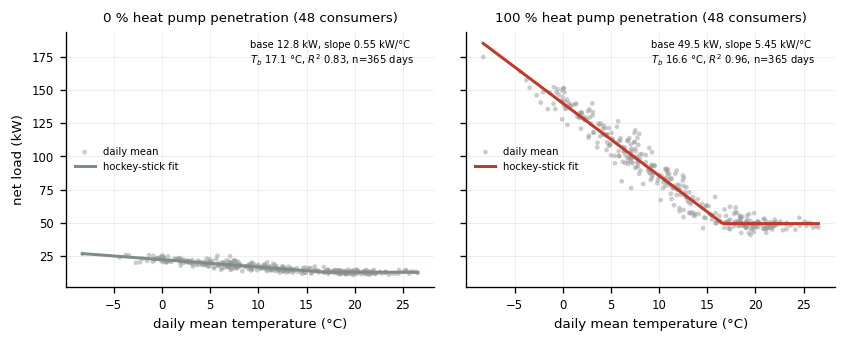

In [4]:
import hp_figures as hf
hf.use_style()

# Same N_total, the two extremes of penetration, best-fitting substation
# in each group -- a clean look at what the model recovers, not a typical
# one. Every point plotted is a real day, nothing here is synthetic.
n_max = int(d24.N_total.max())
sid_no_hp = int(d24[(d24.hp_ratio == 0.0) & (d24.N_total == n_max)]
              .sort_values('r2', ascending=False).substation_id.iloc[0])
sid_all_hp = int(d24[(d24.hp_ratio == 1.0) & (d24.N_total == n_max)]
               .sort_values('r2', ascending=False).substation_id.iloc[0])
hf.fig_hockey_stick_example(design, sid_no_hp, sid_all_hp)
print(f'substation {sid_no_hp} (0 % penetration) vs {sid_all_hp} (100 %), '
      f'both N_total = {n_max}')


## 1. Net-load hockey stick — slope and threshold temperature

Daily means (24 h). The slope distribution is shown separately for
substations with and without heat pumps.


  parameter    n  median     q25     q75      min   max
      slope 1500   1.258   0.352   2.587    0.000  6.00
T_threshold 1500  16.638  16.293  17.204    8.000 20.00
     T_crit 1200 -40.009 -44.023 -34.974 -107.847 -0.67


written paper\figures\fig_s1_slope_threshold_hist.pdf and paper\figures\fig_s1_slope_threshold_hist.png
median slope: no HP 0.122 vs with HP 1.681 kW/°C
threshold temperature is stable at 16.64 °C (IQR 16.29-17.20)

response    n  pinned_low  pinned_high  pinned_frac  median_all  median_unpinned   shift
    Load 1500          11           39       0.0333     16.6383          16.6279 -0.0104
      SF 1200           0            1       0.0008     16.4389          16.4381 -0.0009


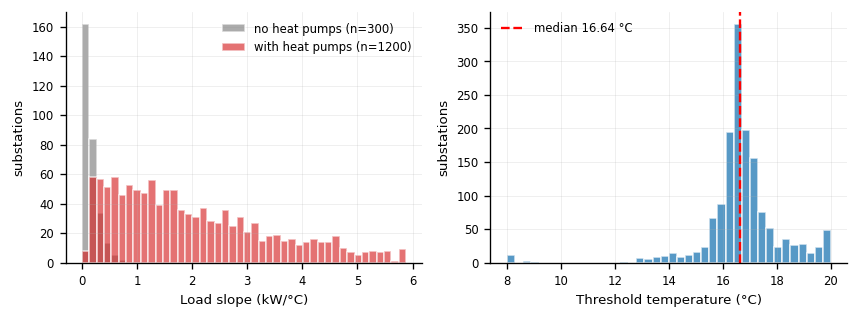

In [5]:
print(ha.describe_params(fits, 'Load').round(3).to_string(index=False))

no_hp = d24[d24.N_hp == 0]
with_hp = d24[d24.N_hp > 0]

fig, axs = plt.subplots(1, 2, figsize=(hf.COL2, 2.7))
bins = np.linspace(0, d24.slope.quantile(.99), 45)
axs[0].hist(no_hp.slope, bins=bins, alpha=.65, label=f'no heat pumps (n={len(no_hp)})',
            color='tab:grey', edgecolor='white')
axs[0].hist(with_hp.slope, bins=bins, alpha=.65, label=f'with heat pumps (n={len(with_hp)})',
            color='tab:red', edgecolor='white')
axs[0].set_xlabel('Load slope (kW/°C)'); axs[0].set_ylabel('substations')
axs[0].grid(alpha=.3); axs[0].legend()

axs[1].hist(d24.T_threshold, bins=40, color='tab:blue', alpha=.75, edgecolor='white')
axs[1].axvline(d24.T_threshold.median(), color='red', ls='--',
               label=f'median {d24.T_threshold.median():.2f} °C')
axs[1].set_xlabel('Threshold temperature (°C)'); axs[1].set_ylabel('substations')
axs[1].grid(alpha=.3); axs[1].legend()
fig.tight_layout()
p = hf.save(fig, 'fig_s1_slope_threshold_hist')
print('written', p + '.pdf', 'and', p + '.png')

print(f'median slope: no HP {no_hp.slope.median():.3f} vs with HP '
      f'{with_hp.slope.median():.3f} kW/°C')
print(f'threshold temperature is stable at {d24.T_threshold.median():.2f} °C '
      f'(IQR {d24.T_threshold.quantile(.25):.2f}-{d24.T_threshold.quantile(.75):.2f})')

# A fit sitting on the search bound has not identified a breakpoint from the
# data. Report how many, and whether dropping them moves the median.
print()
print(ha.boundary_report(fits).round(4).to_string(index=False))


## 2. At what slope is a heat pump detectable?

Whether a substation "has a heat pump" is really three questions.

1. **Is there electrically-driven heating at all?** A threshold on the slope
   answers this, but only ever this. This section answers question 1.
2. **How much?** The magnitude is confounded with consumer count, which is
   what the rest of this section and the heatmap below cover.
3. **What technology?** Heat pump or resistive. Section 2d attempts this.

The heatmap below shows the full surface -- raw slope, and slope normalised
by peak load -- and the cell after it locates a pair of substations from the
data to illustrate the consumer-count confound.

Whether the slope should be **normalised** by something observable without a
household census -- peak load or base load, never the consumer count -- is
tested directly below.

Each candidate is scored by AUC, and the operating threshold is set at **95 %
specificity** -- i.e. at most 5 % of heat-pump-free substations are flagged.


In [6]:
# Substations are the resampling unit. The operating threshold is the 95th
# percentile of the HP-free group, so it is itself an estimate.
N_BOOT = 1000
boot = ha.bootstrap_table(load_fits, n_boot=N_BOOT)
print(f'Detection statistics at 24 h, {N_BOOT} bootstrap replicates, '
      'specificity 0.95:')
print(boot.round(4).to_string(index=False))


Detection statistics at 24 h, 1000 bootstrap replicates, specificity 0.95:
     statistic    auc  auc_lo  auc_hi  threshold  thr_lo  thr_hi  sensitivity  sens_lo  sens_hi
         slope 0.9741  0.9673  0.9805     0.4518  0.3611   0.495       0.8750   0.8533   0.9133
slope_per_peak 0.9895  0.9827  0.9949     0.0218  0.0183   0.023       0.9583   0.9241   0.9842
slope_per_base 0.9868  0.9748  0.9958     0.0496  0.0425   0.058       0.9792   0.9442   0.9925


In [7]:
# The design realises every (N_total, ratio) cell, so the confound reads
# straight off two slices: a row (fixed penetration, N_total varying) and a
# column (fixed N_total, penetration varying). Both are additive in N_total
# and N_hp, which is what the least-squares decomposition below assumes.
piv = d24.pivot_table(index='hp_ratio', columns='N_total', values='slope',
                      aggfunc='median')
print('Median Load slope (kW/degC) at 24 h, rows = penetration, columns =')
print('consumers:')
print(piv.round(2).rename(index=lambda r: f'{r:.0%}').to_string())
print()

n_max = int(piv.columns.max())
print(f'Consumer effect at FIXED penetration, 4 -> {n_max} consumers:')
for ratio in piv.index:
    a, b = piv.loc[ratio, 4], piv.loc[ratio, n_max]
    print(f'  {ratio:>4.0%}:  {a:5.2f} -> {b:5.2f} kW/degC  (x{b / a:.2f})')
print()

print(f'Penetration effect at FIXED consumer count, 0 -> 100%:')
for ntot in piv.columns:
    a, b = piv.loc[0.0, ntot], piv.loc[1.0, ntot]
    print(f'  N_total = {int(ntot):>3}:  {a:5.2f} -> {b:5.2f} kW/degC  (x{b / a:.2f})')
print()

# Both counts raise the slope roughly additively in N_total and N_hp (not
# ratio), so a decomposition against the two counts is what summarises the
# surface, matching how the confound is stated everywhere else.
g = d24.groupby(['N_total', 'N_hp']).slope.median().reset_index()
# Fitted THROUGH THE ORIGIN, matching s_h = N*sigma_base + N_hp*sigma_hp as
# written. A free intercept fits marginally better (R2 0.9988 vs 0.9986) but
# is not in the equation, and it drives the smallest heat-pump-free cells
# negative: at N_total=4 it predicts -0.016 kW/degC against 0.032 observed.
X = np.column_stack([g.N_total, g.N_hp])
c_tot, c_hp = np.linalg.lstsq(X, g.slope.values, rcond=None)[0]
resid = g.slope.values - X @ np.array([c_tot, c_hp])
r2 = 1 - (resid ** 2).sum() / ((g.slope.values - g.slope.values.mean()) ** 2).sum()
print(f'least squares through the origin: slope = '
      f'{c_tot:.4f} per consumer + {c_hp:.4f} per heat pump  (R2 {r2:.4f})')
print(f'one heat pump is worth about {c_hp / c_tot:.0f} ordinary consumers.')
print()

extremes = ha.confound_extremes(d24)
print(f"{extremes['free_N_total']} consumers with no heat pump at all: "
      f"{extremes['free_value']:.2f} kW/degC.")
if extremes['beaten']:
    b = extremes['beaten']
    print(f"{b['N_total']}-consumer substation at {b['hp_ratio']:.0%} "
          f"penetration: {b['value']:.2f} kW/degC.")
else:
    print('No cell in this design is out-sloped by it.')


Median Load slope (kW/degC) at 24 h, rows = penetration, columns =
consumers:
N_total     4     8     12    16    20    24    28    32    36    40    44    48
hp_ratio                                                                        
0%        0.03  0.10  0.04  0.07  0.08  0.09  0.16  0.21  0.19  0.24  0.21  0.27
25%       0.18  0.24  0.36  0.50  0.68  0.74  0.92  1.20  1.23  1.43  1.68  1.64
50%       0.24  0.43  0.77  0.99  1.25  1.49  1.77  2.08  2.28  2.65  2.76  2.98
75%       0.34  0.61  1.06  1.55  1.84  2.14  2.56  2.96  3.37  3.68  4.18  4.46
100%      0.54  0.86  1.40  1.98  2.44  2.83  3.47  3.86  4.50  4.93  5.44  5.90

Consumer effect at FIXED penetration, 4 -> 48 consumers:
    0%:   0.03 ->  0.27 kW/degC  (x8.39)
   25%:   0.18 ->  1.64 kW/degC  (x9.06)
   50%:   0.24 ->  2.98 kW/degC  (x12.57)
   75%:   0.34 ->  4.46 kW/degC  (x13.25)
  100%:   0.54 ->  5.90 kW/degC  (x10.95)

Penetration effect at FIXED consumer count, 0 -> 100%:
  N_total =   4:   0.03 ->  0.54 

In [8]:
# Does the residual electric heating inside the HEAT PUMP tier matter? The
# strict variant excludes it as well, which caps N_total at 20 (21 clean heat
# pumps). If the two agree where they overlap, keeping the full pool costs
# nothing.
strict = pd.read_parquet('data/ratio_strict_fits.parquet')
s24 = strict[(strict.response == 'Load') & (strict.resolution == '24 h') &
             (~strict.failed)]
piv_strict = s24.pivot_table(index='hp_ratio', columns='N_total', values='slope',
                             aggfunc='median')
shared_n = [c for c in piv_strict.columns if c in piv.columns]
delta = piv_strict[shared_n] - piv[shared_n]
print(f'strict minus adopted rule, kW/degC (heat pump tier cleaned as well, '
      f'N_total <= {max(shared_n)}):')
print(delta.round(2).rename(index=lambda r: f'{r:.0%}').to_string())
print()
print(f'largest disagreement {delta.abs().max().max():.2f} kW/degC, '
      f'median {delta.stack().median():+.2f}')


strict minus adopted rule, kW/degC (heat pump tier cleaned as well, N_total <= 20):
N_total     4     8     12    16    20
hp_ratio                              
0%        0.00 -0.01  0.01 -0.02  0.01
25%      -0.03  0.04  0.11  0.00  0.00
50%       0.02  0.07 -0.05  0.07  0.09
75%       0.01  0.16  0.01 -0.15  0.07
100%     -0.04  0.08  0.02 -0.03 -0.02

largest disagreement 0.16 kW/degC, median +0.01


raw slope: detect when statistic > 0.4518 kW/°C  -> sensitivity 0.875 at FPR 0.050
   by penetration: 25%=0.75  50%=0.86  75%=0.92  100%=0.97

slope / peak load: detect when statistic > 0.0218 1/°C  -> sensitivity 0.958 at FPR 0.050
   by penetration: 25%=0.87  50%=0.97  75%=1.00  100%=1.00



written paper\figures\fig_s2_roc_detection.pdf and paper\figures\fig_s2_roc_detection.png
        statistic    AUC  sensitivity  lowest penetration (25%)
slope / peak load 0.9895       0.9583                    0.8667
slope / base load 0.9868       0.9792                    0.9233
        raw slope 0.9741       0.8750                    0.7500

On this design the best statistic is slope / peak load.


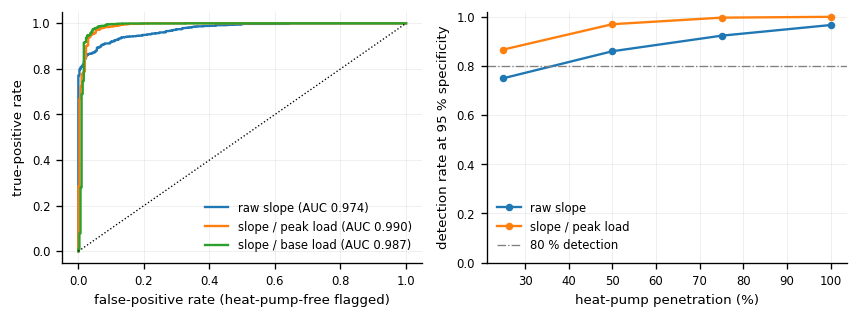

In [9]:
# hp_ratio is exactly one of 0, 25, 50, 75, 100 % by construction, so detection
# against penetration is reported at those literal values -- no binning or
# quantile grouping needed, unlike the earlier design where nearly every cell
# realised a ratio of its own.
det_raw = ha.detection_threshold(load_fits, 'slope')
det_norm = ha.detection_threshold(load_fits, 'slope_per_peak')

for name, det, unit in [('raw slope', det_raw, ' kW/°C'),
                        ('slope / peak load', det_norm, ' 1/°C')]:
    print(f'{name}: detect when statistic > {det["threshold"]:.4f}{unit}'
          f'  -> sensitivity {det["sensitivity"]:.3f} at FPR {det["observed_fpr"]:.3f}')
    print('   by penetration: ' +
          '  '.join(f'{r:.0%}={v:.2f}' for r, v in det['by_hp_ratio'].items()))
    print()

fig, axs = plt.subplots(1, 2, figsize=(hf.COL2, 2.7))
for stat, lab in [('slope', 'raw slope'), ('slope_per_peak', 'slope / peak load'),
                  ('slope_per_base', 'slope / base load')]:
    curve, auc = ha.roc(load_fits, stat)
    axs[0].plot(curve.fpr, curve.tpr, label=f'{lab} (AUC {auc:.3f})')
axs[0].plot([0, 1], [0, 1], 'k:', lw=.8)
axs[0].set_xlabel('false-positive rate (heat-pump-free flagged)')
axs[0].set_ylabel('true-positive rate')
axs[0].grid(alpha=.3); axs[0].legend()

for det, lab in [(det_raw, 'raw slope'), (det_norm, 'slope / peak load')]:
    s = det['by_hp_ratio']
    axs[1].plot(s.index * 100, s.values, 'o-', label=lab)
axs[1].axhline(.8, color='grey', ls='-.', lw=.8, label='80 % detection')
axs[1].set_xlabel('heat-pump penetration (%)')
axs[1].set_ylabel('detection rate at 95 % specificity')
axs[1].set_ylim(0, 1.02); axs[1].grid(alpha=.3); axs[1].legend()
fig.tight_layout()
p = hf.save(fig, 'fig_s2_roc_detection')
print('written', p + '.pdf', 'and', p + '.png')

# Which statistic actually wins on this design?
_cmp = []
for st, nm in [('slope', 'raw slope'), ('slope_per_peak', 'slope / peak load'),
               ('slope_per_base', 'slope / base load')]:
    _d = ha.detection_threshold(load_fits, st, '24 h')
    _, _a = ha.roc(load_fits, st, '24 h')
    _cmp.append({'statistic': nm, 'AUC': _a, 'sensitivity': _d['sensitivity'],
                 'lowest penetration (25%)': _d['by_hp_ratio'].get(0.25, float('nan'))})
_cmp = pd.DataFrame(_cmp).sort_values('AUC', ascending=False)
print(_cmp.round(4).to_string(index=False))
print()
_best = _cmp.iloc[0].statistic
print(f'On this design the best statistic is {_best}.')


In [10]:
# Sensitivity inherits the threshold's uncertainty, which is why its interval
# is so much wider than the AUC interval.
b = boot.set_index('statistic').loc['slope_per_peak']
print(f"slope / peak load at 24 h")
print(f"  AUC         {b.auc:.3f}  [{b.auc_lo:.3f}, {b.auc_hi:.3f}]")
print(f"  threshold   {b.threshold:.4f}  [{b.thr_lo:.4f}, {b.thr_hi:.4f}] 1/degC")
print(f"  sensitivity {b.sensitivity:.3f}  [{b.sens_lo:.3f}, {b.sens_hi:.3f}]")
print()
thr_lo_pc = 100 * (b.thr_lo / b.threshold - 1)
thr_hi_pc = 100 * (b.thr_hi / b.threshold - 1)
print(f'threshold estimated to {thr_lo_pc:+.0f}/{thr_hi_pc:+.0f} per cent; '
      f'sensitivity spans {b.sens_lo:.2f} to {b.sens_hi:.2f}')


slope / peak load at 24 h
  AUC         0.990  [0.983, 0.995]
  threshold   0.0218  [0.0183, 0.0230] 1/degC
  sensitivity 0.958  [0.924, 0.984]

threshold estimated to -16/+5 per cent; sensitivity spans 0.92 to 0.98


In [11]:
# Whether detectability really peaks at an intermediate resolution needs a test,
# not just five separate point estimates. The same substations appear at every
# resolution, so each replicate resamples substations once and evaluates all
# resolutions on that draw, giving a paired difference.
res_contrast, ref_res = ha.bootstrap_resolution_contrast(
    load_fits, 'slope_per_peak', reference='24 h', n_boot=N_BOOT)
print(f'Paired contrast against {ref_res}:')
print(res_contrast.round(4).to_string(index=False))
print()
sig_auc = res_contrast[(res_contrast.d_auc_lo > 0) | (res_contrast.d_auc_hi < 0)]
sig_sen = res_contrast[(res_contrast.d_sens_lo > 0) | (res_contrast.d_sens_hi < 0)]
print('AUC differs from 24 h at:        ' + ', '.join(sig_auc.resolution))
print('sensitivity differs from 24 h at: ' + ', '.join(sig_sen.resolution))


Paired contrast against 24 h:
resolution    auc  sensitivity  d_auc_vs_ref  d_auc_lo  d_auc_hi  d_sens_vs_ref  d_sens_lo  d_sens_hi
       1 h 0.9927       0.9700        0.0032   -0.0002    0.0081         0.0033    -0.0217     0.0267
       4 h 0.9944       0.9742        0.0049    0.0013    0.0097         0.0121    -0.0058     0.0367
       8 h 0.9944       0.9750        0.0049    0.0015    0.0099         0.0130    -0.0017     0.0384
      16 h 0.9918       0.9650        0.0023    0.0005    0.0046         0.0060    -0.0092     0.0292
      24 h 0.9895       0.9583        0.0000    0.0000    0.0000         0.0000     0.0000     0.0000

AUC differs from 24 h at:        4 h, 8 h, 16 h
sensitivity differs from 24 h at: 


## 2b. Composition of the reference group

Every result so far fixes `eheat_frac = 0.0`: no non-heat-pump member has any
other electric heating. The observed prevalence of other electric heating
among non-heat-pump-eligible households in the combined pool is 19.4 % (314
of 1621, all on station KLO).

Three designs are compared, differing only in `eheat_frac`: 0.0 (already
built, the current analysis set), 0.1937 (the observed prevalence), and 1.0
(every non-heat-pump member has other electric heating). Everything else is
unchanged -- same N_total x ratio grid, same heat pump tier, same seed.


In [12]:
design_e0, design_eobs, design_e1 = design, None, None
fits_e0 = fits
design_eobs = hd.load_design('data/design_ratio_eheatobs.pkl')
design_e1 = hd.load_design('data/design_ratio_eheat1.pkl')
fits_eobs = pd.read_parquet('data/ratio_fits_eheatobs.parquet')
fits_e1 = pd.read_parquet('data/ratio_fits_eheat1.parquet')

arms = [('0.0 (clean)', design_e0, fits_e0),
       ('0.1937 (observed)', design_eobs, fits_eobs),
       ('1.0 (saturated)', design_e1, fits_e1)]

rows = []
for label, D, F in arms:
    m = D['meta']
    ctrl = m[m.N_hp == 0]
    realised = (ctrl.N_eheat_realised / ctrl.N_total).mean()
    L = F[(F.response == 'Load') & (F.resolution == '24 h') & (~F.failed)]
    row = {'eheat_frac': label,
           'realised share in controls': realised,
           'control median slope': L[L.N_hp == 0].slope.median()}
    for stat in ['slope', 'slope_per_peak']:
        det = ha.detection_threshold(L, stat, '24 h')
        _, auc = ha.roc(L, stat, '24 h')
        row[f'{stat} AUC'] = auc
        row[f'{stat} sensitivity'] = det['sensitivity']
    rows.append(row)
print(pd.DataFrame(rows).round(4).to_string(index=False))


       eheat_frac  realised share in controls  control median slope  slope AUC  slope sensitivity  slope_per_peak AUC  slope_per_peak sensitivity
      0.0 (clean)                      0.0000                0.1222     0.9741             0.8750              0.9895                      0.9583
0.1937 (observed)                      0.2013                0.3461     0.9027             0.7167              0.9208                      0.5475
  1.0 (saturated)                      1.0000                1.2647     0.7175             0.3958              0.6660                      0.0342


In [13]:
# The peak-load normalisation is not just weaker under contamination, it can
# invert. Check whether the mechanism is that other electric heating inflates
# peak load along with slope, so the ratio does not separate as intended.
for label, D, F in arms:
    L = F[(F.response == 'Load') & (F.resolution == '24 h') & (~F.failed)]
    ctrl = L[L.N_hp == 0]
    print(f'eheat_frac={label:20s} control peak load median '
          f'{ctrl.peak_load.median():6.2f} kW   control slope median '
          f'{ctrl.slope.median():.3f} kW/degC')
print()
_e0 = pd.DataFrame(rows).set_index('eheat_frac')
print(f"AUC at saturation: raw slope {_e0.loc['1.0 (saturated)', 'slope AUC']:.2f}, "
      f"slope/peak {_e0.loc['1.0 (saturated)', 'slope_per_peak AUC']:.2f}")


eheat_frac=0.0 (clean)          control peak load median  13.28 kW   control slope median 0.122 kW/degC
eheat_frac=0.1937 (observed)    control peak load median  19.04 kW   control slope median 0.346 kW/degC
eheat_frac=1.0 (saturated)      control peak load median  46.26 kW   control slope median 1.265 kW/degC

AUC at saturation: raw slope 0.72, slope/peak 0.67


## 2c. Detection by penetration

hp_ratio is exactly one of 25, 50, 75 or 100 % among substations with a heat
pump, by construction. Detection is checked at each N_total separately, not
only pooled across N_total, to see whether a nominal penetration level means
the same thing at every consumer count.


In [14]:
pos = d24[d24.N_hp > 0].copy()
for stat in ['slope', 'slope_per_peak']:
    det = ha.detection_threshold(d24, stat, '24 h')
    print(f'{stat:16s} AUC computed above; threshold {det["threshold"]:.4f}')
    print('  by penetration: ' +
          '  '.join(f'{r:.0%}={v:.2f}' for r, v in det['by_hp_ratio'].items()))
    print()


slope            AUC computed above; threshold 0.4518
  by penetration: 25%=0.75  50%=0.86  75%=0.92  100%=0.97

slope_per_peak   AUC computed above; threshold 0.0218
  by penetration: 25%=0.87  50%=0.97  75%=1.00  100%=1.00



In [15]:
# Substations per penetration level, by N_total -- confirms every ratio is
# realised at every size (25 replicates each, by construction).
print('substations per penetration level, by N_total:')
print(pd.crosstab(pos.hp_ratio, pos.N_total).to_string())


substations per penetration level, by N_total:
N_total   4   8   12  16  20  24  28  32  36  40  44  48
hp_ratio                                                
0.25      25  25  25  25  25  25  25  25  25  25  25  25
0.50      25  25  25  25  25  25  25  25  25  25  25  25
0.75      25  25  25  25  25  25  25  25  25  25  25  25
1.00      25  25  25  25  25  25  25  25  25  25  25  25


In [16]:
# Detection rate by penetration x N_total, both statistics, at the thresholds
# from cell 13.
for stat in ['slope', 'slope_per_peak']:
    thr = ha.detection_threshold(d24, stat, '24 h')['threshold']
    flag = pos[stat] >= thr
    grid = pd.crosstab(pos.hp_ratio, pos.N_total, values=flag, aggfunc='mean').round(2)
    print(f'{stat}: detection rate by penetration x N_total')
    print(grid.rename(index=lambda r: f'{r:.0%}').to_string())
    spread = (grid.max(axis=1) - grid.min(axis=1)).dropna()
    worst = spread.idxmax()
    print(f'  widest within-ratio spread across N_total: {worst:.0%}, '
          f'{spread[worst]:.2f} ({grid.loc[worst].min():.2f} to '
          f'{grid.loc[worst].max():.2f})')
    print()


slope: detection rate by penetration x N_total
N_total     4     8     12    16   20   24   28   32   36   40   44   48
hp_ratio                                                                
25%       0.00  0.04  0.32  0.64  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
50%       0.00  0.32  1.00  1.00  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
75%       0.08  1.00  1.00  1.00  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
100%      0.60  1.00  1.00  1.00  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
  widest within-ratio spread across N_total: 25%, 1.00 (0.00 to 1.00)

slope_per_peak: detection rate by penetration x N_total
N_total     4     8    12    16    20   24    28    32    36    40   44   48
hp_ratio                                                                    
25%       0.60  0.64  0.8  0.92  0.84  0.8  0.92  0.96  0.96  0.96  1.0  1.0
50%       0.76  0.88  1.0  1.00  1.00  1.0  1.00  1.00  1.00  1.00  1.0  1.0
75%       0.96  1.00  1.0  1.00  1.00  1.0  1.00  1.00  1.00  1.00  1.0  1.0
100

## 2d. What technology? (attempted)

A heat pump draws `Q_heat(T) / COP(T)`, and COP falls as it gets colder, so
its electrical load would curve upward -- convex -- below the balance
temperature if COP is the dominant effect. Resistive heating has COP = 1 and
stays linear. A quadratic term added to the cold side of the hockey stick is
tested as a candidate technology fingerprint.

This is tested on the submetered heat pump circuits themselves, individually,
normalised to each household's own installed capacity (the same SF
construction used elsewhere in this notebook), before being asked of any
substation aggregate.


In [17]:
import hp_pools as hpp
from scipy import stats

pool = hpp.build_pool_combined(verbose=False)
curv = ha.curvature_test(pool, agg='mean')
print(f'{len(curv)} of {len(pool["hp_households"])} submetered heat pump '
      f'circuits give a usable fit')
print()
frac_pos = (curv.curvature > 0).mean()
w = stats.wilcoxon(curv.curvature)
print(f'households with positive (convex) curvature: {frac_pos:.1%}')
print(f'median curvature coefficient: {curv.curvature.median():.2e}')
print(f'median R2 gained by the quadratic term: {curv.d_r2.median():.4f}')
print(f'Wilcoxon signed-rank test, curvature != 0: '
      f'statistic {w.statistic:.0f}, p = {w.pvalue:.3f}')


81 of 81 submetered heat pump circuits give a usable fit

households with positive (convex) curvature: 42.0%
median curvature coefficient: -3.82e-05
median R2 gained by the quadratic term: 0.0015
Wilcoxon signed-rank test, curvature != 0: statistic 1363, p = 0.161


A second daily convention is also tested here: daily MINIMUM temperature
against daily MAXIMUM load (used elsewhere in `hp_common`), instead of the
daily-mean convention used everywhere else in this notebook.


In [18]:
curv_mm = ha.curvature_test(pool, agg='minmax')
frac_pos_mm = (curv_mm.curvature > 0).mean()
w_mm = stats.wilcoxon(curv_mm.curvature)
print(f'{len(curv_mm)} households, daily min-T / max-SF')
print(f'households with positive (convex) curvature: {frac_pos_mm:.1%}')
print(f'median curvature coefficient: {curv_mm.curvature.median():.2e}')
print(f'median R2 gained by the quadratic term: {curv_mm.d_r2.median():.4f}')
print(f'Wilcoxon signed-rank test, curvature != 0: '
      f'statistic {w_mm.statistic:.0f}, p = {w_mm.pvalue:.2e}')


81 households, daily min-T / max-SF
households with positive (convex) curvature: 9.9%
median curvature coefficient: -7.78e-04
median R2 gained by the quadratic term: 0.0200
Wilcoxon signed-rank test, curvature != 0: statistic 198, p = 5.74e-12


The hockey stick estimates its own breakpoint. Heating degree hours instead fix
a base temperature and integrate the shortfall below it, so the hinge sits in the
regressor and the model becomes a plain line. The two parameterisations make
different assumptions, so running the identical detection analysis on both
separates what is a property of the estimator from what is a property of the
problem.

The base temperature is each substation own hockey-stick T_threshold, not a
single constant applied to everyone (hp_common HDH_THRESH, fixed at 12 degC, is
kept only as the fallback for a substation with no threshold to borrow). With a
shared threshold, the one remaining difference between the two
parameterisations is what each is built from: the hockey stick evaluates a
single daily-mean temperature against the threshold, HDH integrates the
substation true sub-daily temperature profile below it. Comparing them now
isolates that difference specifically, rather than mixing it with a difference
in WHERE the threshold sits.


In [19]:
HDH_FITS_PATH = 'data/ratio_hdh_fits.parquet'
REFIT_HDH = False

if REFIT_HDH or REFIT or REGENERATE_DESIGN:
    # each substation's own hockey-stick threshold, not one constant for all
    _thresholds = d24.set_index('substation_id')['T_threshold']
    hdh_fits = ha.fit_hdh_all(design, thresholds=_thresholds)
    hdh_fits.to_parquet(HDH_FITS_PATH)
else:
    hdh_fits = pd.read_parquet(HDH_FITS_PATH)

hok = hdh_fits[~hdh_fits.failed]
print(f'HDH base temperature, per substation: median {hok.hdh_threshold.median():.1f} '
      f'degC, range {hok.hdh_threshold.min():.1f}-{hok.hdh_threshold.max():.1f} '
      f'(borrowed from each substation own hockey-stick threshold)')
print(f'{len(hdh_fits)} fits, {int(hdh_fits.failed.sum())} failed, '
      f'median R2 {hok.r2.median():.3f}')
print(f'slope kW per degC.h : no heat pumps {hok[hok.N_hp == 0].slope.median():.4f}, '
      f'with heat pumps {hok[hok.N_hp > 0].slope.median():.4f}')


HDH base temperature, per substation: median 16.6 degC, range 8.0-20.0 (borrowed from each substation own hockey-stick threshold)
1500 fits, 0 failed, median R2 0.919
slope kW per degC.h : no heat pumps 0.0053, with heat pumps 0.0728


In [20]:
# The same detection analysis, run on both parameterisations.
param_cmp = ha.parameterisation_comparison(load_fits, hdh_fits, n_boot=N_BOOT)
print(param_cmp.round(4).to_string(index=False))
print()

print('Detection rate against penetration, slope normalised by peak load:')
for nm, df in [('hockey stick', load_fits), ('HDH linear', hdh_fits)]:
    det = ha.detection_threshold(df, 'slope_per_peak', '24 h')
    print(f'  {nm:13s} ' + '  '.join(f'{r:.0%}={v:.2f}'
                                     for r, v in det['by_hp_ratio'].items()))
print()

# The confound is that the raw slope grows with consumers even when no heat
# pump is present. Check whether that survives the change of parameterisation.
print('Median raw slope of HP-free substations, by substation size:')
for nm, df in [('hockey stick', load_fits[load_fits.resolution == '24 h']),
               ('HDH linear', hdh_fits)]:
    z = df[(~df.failed) & (df.N_hp == 0)].groupby('N_total').slope.median()
    print(f'  {nm:13s} ' + '  '.join(f'N={int(k)}: {v:.3f}' for k, v in z.items()))
print()
_hs = load_fits[(load_fits.resolution == '24 h') & (~load_fits.failed) &
                (load_fits.N_hp == 0)].groupby('N_total').slope.median()
_hd = hdh_fits[(~hdh_fits.failed) & (hdh_fits.N_hp == 0)
               ].groupby('N_total').slope.median()
_auc = param_cmp.set_index(['parameterisation', 'statistic']).auc
_det = {nm: ha.detection_threshold(df, 'slope_per_peak', '24 h')['by_hp_ratio']
        for nm, df in [('hockey stick', load_fits), ('HDH linear', hdh_fits)]}
print(f'raw slope of HP-free substations rises by a factor of '
      f'{_hs.iloc[-1] / _hs.iloc[0]:.0f} (hockey stick) and '
      f'{_hd.iloc[-1] / _hd.iloc[0]:.0f} (HDH), smallest to largest substation')
print(f"AUC after normalising by peak load: "
      f"{_auc[('hockey stick', 'slope_per_peak')]:.3f} (hockey stick), "
      f"{_auc[('HDH linear', 'slope_per_peak')]:.3f} (HDH)")
_lo_ratio = _det['hockey stick'].index[0]
print(f"detection at {_lo_ratio:.0%} penetration: "
      f"{_det['hockey stick'].loc[_lo_ratio]:.2f} (hockey stick), "
      f"{_det['HDH linear'].loc[_lo_ratio]:.2f} (HDH)")


parameterisation      statistic    auc  auc_lo  auc_hi  threshold  sensitivity  sens_lo  sens_hi
    hockey stick          slope 0.9741  0.9673  0.9805     0.4518       0.8750   0.8533   0.9133
    hockey stick slope_per_peak 0.9895  0.9827  0.9949     0.0218       0.9583   0.9241   0.9842
    hockey stick slope_per_base 0.9868  0.9748  0.9958     0.0496       0.9792   0.9442   0.9925
      HDH linear          slope 0.9741  0.9673  0.9805     0.0197       0.8750   0.8516   0.9142
      HDH linear slope_per_peak 0.9898  0.9833  0.9949     0.0009       0.9567   0.9250   0.9842
      HDH linear slope_per_base 0.9869  0.9749  0.9957     0.0022       0.9783   0.9441   0.9917

Detection rate against penetration, slope normalised by peak load:
  hockey stick  25%=0.87  50%=0.97  75%=1.00  100%=1.00
  HDH linear    25%=0.86  50%=0.97  75%=1.00  100%=1.00

Median raw slope of HP-free substations, by substation size:
  hockey stick  N=4: 0.032  N=8: 0.099  N=12: 0.041  N=16: 0.065  N=20: 0.084  

### 2e. Detection by resolution

Every result above uses 24 h means. `ha.detection_threshold`, `ha.roc` and
`ha.bootstrap_resolution_contrast` all take a `resolution` argument; this
section runs them at every resolution in the design (1 h, 4 h, 8 h, 16 h,
24 h) instead of only the default, for both the raw slope and slope
normalised by peak load.


resolution      statistic  threshold    auc  sensitivity
       1 h          slope     0.3919 0.9823       0.8983
       1 h slope_per_peak     0.0106 0.9927       0.9700
       4 h          slope     0.3991 0.9817       0.8975
       4 h slope_per_peak     0.0131 0.9944       0.9742
       8 h          slope     0.4103 0.9812       0.8975
       8 h slope_per_peak     0.0160 0.9944       0.9750
      16 h          slope     0.4369 0.9759       0.8800
      16 h slope_per_peak     0.0194 0.9918       0.9650
      24 h          slope     0.4518 0.9741       0.8750
      24 h slope_per_peak     0.0218 0.9895       0.9583


written paper\figures\fig_s3_auc_by_resolution.pdf and paper\figures\fig_s3_auc_by_resolution.png


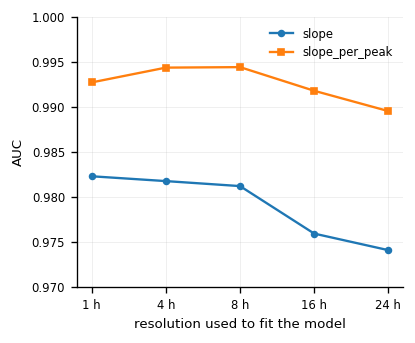

In [21]:
res_order = ['1 h', '4 h', '8 h', '16 h', '24 h']
det_by_res = []
for res in res_order:
    for stat in ['slope', 'slope_per_peak']:
        det = ha.detection_threshold(load_fits, stat, res)
        _, auc = ha.roc(load_fits, stat, res)
        det_by_res.append({'resolution': res, 'statistic': stat,
                           'threshold': det['threshold'], 'auc': auc,
                           'sensitivity': det['sensitivity']})
det_by_res = pd.DataFrame(det_by_res)
print(det_by_res.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(hf.COL1, 2.9))
for stat, mk in [('slope', 'o'), ('slope_per_peak', 's')]:
    d = det_by_res[det_by_res.statistic == stat]
    ax.plot(d.resolution, d.auc, marker=mk, label=stat)
ax.set_xlabel('resolution used to fit the model')
ax.set_ylabel('AUC')
# the whole effect lives in the top 3 % of the axis; a 0-1 view hides it
ax.set_ylim(0.97, 1.0)
ax.grid(alpha=.3); ax.legend()
fig.tight_layout()
p = hf.save(fig, 'fig_s3_auc_by_resolution')
print('written', p + '.pdf', 'and', p + '.png')


In [22]:
# Paired bootstrap so the resolution comparison shares substations across
# every point -- res_contrast (slope_per_peak) was already computed above,
# for raw slope it is computed fresh here.
res_contrast_slope, _ = ha.bootstrap_resolution_contrast(
    load_fits, 'slope', reference='24 h', n_boot=N_BOOT)
print('raw slope, paired against 24 h:')
print(res_contrast_slope.round(4).to_string(index=False))
print()
print('slope / peak load, paired against 24 h:')
print(res_contrast.round(4).to_string(index=False))


raw slope, paired against 24 h:
resolution    auc  sensitivity  d_auc_vs_ref  d_auc_lo  d_auc_hi  d_sens_vs_ref  d_sens_lo  d_sens_hi
       1 h 0.9823       0.8983        0.0082    0.0064    0.0101         0.0246     0.0108     0.0400
       4 h 0.9817       0.8975        0.0077    0.0060    0.0094         0.0228     0.0092     0.0375
       8 h 0.9812       0.8975        0.0071    0.0056    0.0087         0.0201     0.0058     0.0350
      16 h 0.9759       0.8800        0.0018    0.0014    0.0024         0.0035    -0.0017     0.0117
      24 h 0.9741       0.8750        0.0000    0.0000    0.0000         0.0000     0.0000     0.0000

slope / peak load, paired against 24 h:
resolution    auc  sensitivity  d_auc_vs_ref  d_auc_lo  d_auc_hi  d_sens_vs_ref  d_sens_lo  d_sens_hi
       1 h 0.9927       0.9700        0.0032   -0.0002    0.0081         0.0033    -0.0217     0.0267
       4 h 0.9944       0.9742        0.0049    0.0013    0.0097         0.0121    -0.0058     0.0367
       8 

detection rate by penetration, at each resolution (slope / peak load):
  1 h   25%=0.90  50%=0.98  75%=0.99  100%=1.00
  4 h   25%=0.92  50%=0.98  75%=1.00  100%=1.00
  8 h   25%=0.92  50%=0.98  75%=1.00  100%=1.00
  16 h  25%=0.89  50%=0.97  75%=1.00  100%=1.00
  24 h  25%=0.87  50%=0.97  75%=1.00  100%=1.00


written paper\figures\fig_s4_detection_by_resolution.pdf and paper\figures\fig_s4_detection_by_resolution.png


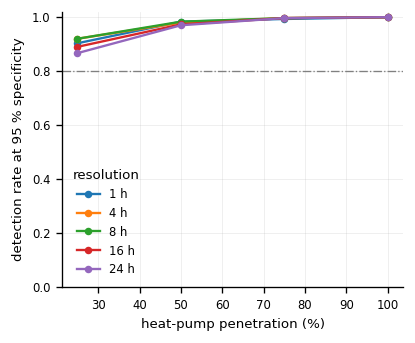

In [23]:
print('detection rate by penetration, at each resolution (slope / peak load):')
for res in res_order:
    det = ha.detection_threshold(load_fits, 'slope_per_peak', res)
    print(f'  {res:5s} ' + '  '.join(f'{r:.0%}={v:.2f}'
                                     for r, v in det['by_hp_ratio'].items()))

fig, ax = plt.subplots(figsize=(hf.COL1, 2.9))
for res in res_order:
    det = ha.detection_threshold(load_fits, 'slope_per_peak', res)
    s = det['by_hp_ratio']
    ax.plot(s.index * 100, s.values, 'o-', label=res)
ax.axhline(.8, color='grey', ls='-.', lw=.8)
ax.set_xlabel('heat-pump penetration (%)')
ax.set_ylabel('detection rate at 95 % specificity')
ax.set_ylim(0, 1.02); ax.grid(alpha=.3); ax.legend(title='resolution')
fig.tight_layout()
p = hf.save(fig, 'fig_s4_detection_by_resolution')
print('written', p + '.pdf', 'and', p + '.png')


## 3. Simultaneity factor

SF is the aggregated heat pump load divided by the sum of the individual
installed peaks, so it is bounded between zero and one. It is defined only
where heat pumps are present, since it requires a submetered heat pump
circuit specifically.

The temperature at which the fitted line would reach SF = 1 is computed
below as a diagnostic of how far the linear extrapolation is pushed beyond
the observed range. The quantity used elsewhere is SF at the coldest
conditions actually observed.

    from the SF fit:   T at SF = 1 is T_threshold minus (1 - base) / slope
    from the load fit: T at SF = 1 is T_threshold minus HP_Peak / slope


  parameter    n  median     q25     q75      min    max
      slope 1200   0.016   0.015   0.017    0.006  0.040
T_threshold 1200  16.439  16.097  16.684   12.497 20.000
     T_crit 1200 -44.479 -48.705 -40.645 -137.338 -9.422


written paper\figures\fig_s5_sf_params_hist.pdf and paper\figures\fig_s5_sf_params_hist.png


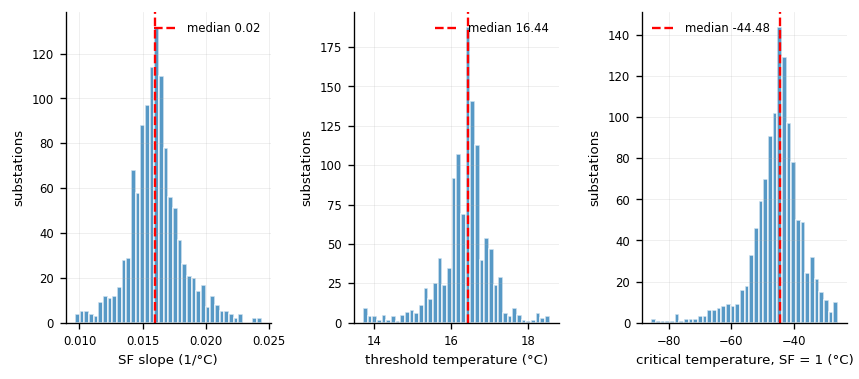

In [24]:
print(ha.describe_params(fits, 'SF').round(3).to_string(index=False))

s24 = sf_fits[(sf_fits.resolution == '24 h') & (~sf_fits.failed)]
specs = [('slope', 'SF slope (1/°C)'), ('T_threshold', 'threshold temperature (°C)'),
         ('T_crit', 'critical temperature, SF = 1 (°C)')]
fig, axs = plt.subplots(1, 3, figsize=(hf.COL2, 3.2))
for ax, (col, lab) in zip(axs, specs):
    v = s24[col].replace([np.inf, -np.inf], np.nan).dropna()
    lo, hi = v.quantile(.01), v.quantile(.99)
    ax.hist(v, bins=40, range=(lo, hi), color='tab:blue', alpha=.75, edgecolor='white')
    ax.axvline(v.median(), color='red', ls='--', label=f'median {v.median():.2f}')
    ax.set_xlabel(lab); ax.set_ylabel('substations'); ax.grid(alpha=.3)
    ax.legend()
fig.tight_layout()
p = hf.save(fig, 'fig_s5_sf_params_hist')
print('written', p + '.pdf', 'and', p + '.png')


In [25]:
# How far is SF = 1 from anything observed? Each substation is evaluated on its
# OWN coldest observed day, using its own fit, and the median is taken across
# substations. Reading one number off the median curve is a different quantity
# and is not what is wanted here.
sf24 = s24.assign(SF_at_coldest=ha.sf_at_coldest(sf_fits, '24 h'))
print(f'coldest observed daily mean : {s24.T_min_obs.median():.1f} °C '
      f'(median over substations)')
print(f'modelled SF on that day     : {sf24.SF_at_coldest.median():.2f}'
      f'  [IQR {sf24.SF_at_coldest.quantile(.25):.2f}, '
      f'{sf24.SF_at_coldest.quantile(.75):.2f}]  '
      f'over {len(sf24)} substations')
print(f'substations reaching SF = 1  : {int((sf24.SF_at_coldest >= 1).sum())} '
      f'of {len(sf24)}')
print()
ld = load_fits[(load_fits.resolution == '24 h') & (load_fits.N_hp > 0)]

# hp_ratio is exactly one of the five grid levels, so grouping directly gives a
# clean table -- no banding needed on this design.
cmp = pd.DataFrame({
    'n_sf': s24[s24.N_hp > 0].groupby('hp_ratio').size(),
    'SF_T_crit': s24[s24.N_hp > 0].groupby('hp_ratio').T_crit.median(),
    'Load_T_crit': ld.groupby('hp_ratio').T_crit.median()})
cmp['gap'] = cmp.Load_T_crit - cmp.SF_T_crit
print('critical temperature: ground truth (SF) vs observable (net load)')
print(cmp.round(1).rename(index=lambda r: f'{r:.0%}').to_string())
print()



coldest observed daily mean : -8.2 °C (median over substations)
modelled SF on that day     : 0.42  [IQR 0.39, 0.45]  over 1200 substations
substations reaching SF = 1  : 0 of 1200

critical temperature: ground truth (SF) vs observable (net load)
          n_sf  SF_T_crit  Load_T_crit  gap
hp_ratio                                   
25%        300      -43.8        -34.0  9.9
50%        300      -44.7        -39.1  5.6
75%        300      -44.9        -41.0  4.0
100%       300      -44.4        -41.5  3.0



The simultaneity factor also sets what the fleet can offer as flexibility. At
a given temperature the fraction of installed capacity currently drawing
power is SF(T); the remainder, 1 - SF(T), is idle.

Both are fractions of installed capacity, not converted to kW.

The curve is drawn across the observed temperature range and a short way
beyond it; the extrapolated part is shown separately since the SF fit is
linear only where it was estimated.


In [26]:
flex, t_range = ha.flexibility_envelope(sf_fits, design)
flex_stats = ha.flexibility_summary(sf_fits, flex, t_range)

print(f'observed daily mean temperature: {t_range[0]:.1f} to {t_range[1]:.1f} degC')
print(f'SF at the coldest observed day : {flex_stats.SF_at_coldest_observed:.3f} '
      f'[IQR {flex_stats.SF_at_coldest_q25:.3f}, '
      f'{flex_stats.SF_at_coldest_q75:.3f}]')
print(f'  median over {int(flex_stats.n_substations)} substations, each on its own '
      f'coldest day')
print(f'  downward flexibility there   : {flex_stats.down_at_coldest:.3f} of capacity')
print(f'  upward flexibility there     : {flex_stats.up_at_coldest:.3f} of capacity')
print(f'dSF/dT                         : {flex_stats.dSF_dT_median:.4f} per degC '
      f'[{flex_stats.dSF_dT_q25:.4f}, {flex_stats.dSF_dT_q75:.4f}]')
print(f'  i.e. {abs(flex_stats.dSF_per_5K):.3f} of capacity per 5 K of cooling')
print()
for T in [-9, -5, 0, 5, 10, 15, 20]:
    if T < t_range[0] or T > t_range[1]:
        continue
    r = flex.iloc[int((flex['T'] - T).abs().values.argmin())]
    print(f'  T = {T:>3} degC   down {r.down_median:.3f}   up {r.up_median:.3f}')


observed daily mean temperature: -9.6 to 27.7 degC
SF at the coldest observed day : 0.421 [IQR 0.395, 0.445]
  median over 1200 substations, each on its own coldest day
  downward flexibility there   : 0.421 of capacity
  upward flexibility there     : 0.579 of capacity
dSF/dT                         : -0.0160 per degC [-0.0171, -0.0149]
  i.e. 0.080 of capacity per 5 K of cooling

  T =  -9 degC   down 0.432   up 0.568
  T =  -5 degC   down 0.370   up 0.630
  T =   0 degC   down 0.290   up 0.710
  T =   5 degC   down 0.209   up 0.791
  T =  10 degC   down 0.130   up 0.870
  T =  15 degC   down 0.050   up 0.950
  T =  20 degC   down 0.027   up 0.973


written paper\figures\fig_s6_flexibility_envelope.pdf and paper\figures\fig_s6_flexibility_envelope.png


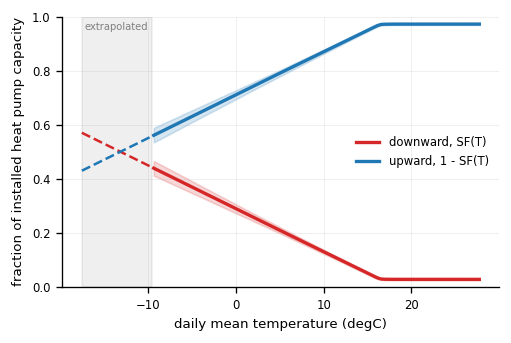

In [27]:
obs = flex[flex.observed]
ext = flex[~flex.observed]

fig, ax = plt.subplots(figsize=(hf.COL1 + 0.8, 2.9))
ax.fill_between(obs['T'], obs.down_q25, obs.down_q75, color='tab:red', alpha=.18)
ax.plot(obs['T'], obs.down_median, color='tab:red', lw=2,
        label='downward, SF(T)')
ax.fill_between(obs['T'], obs.up_q25, obs.up_q75, color='tab:blue', alpha=.18)
ax.plot(obs['T'], obs.up_median, color='tab:blue', lw=2,
        label='upward, 1 - SF(T)')
# extrapolated region, dashed so it is not read as measured
ax.plot(ext['T'], ext.down_median, color='tab:red', lw=1.5, ls='--')
ax.plot(ext['T'], ext.up_median, color='tab:blue', lw=1.5, ls='--')
ax.axvspan(flex['T'].min(), t_range[0], color='grey', alpha=.12)
ax.text(flex['T'].min() + 0.3, 0.95, 'extrapolated', fontsize=6, color='grey')
ax.set_xlabel('daily mean temperature (degC)')
ax.set_ylabel('fraction of installed heat pump capacity')
ax.set_ylim(0, 1); ax.grid(alpha=.3); ax.legend()
fig.tight_layout()
p = hf.save(fig, 'fig_s6_flexibility_envelope')
print('written', p + '.pdf', 'and', p + '.png')


## 4. Fit quality vs resolution and aggregation

Fit quality (R²) is examined against temporal resolution (1 h to 24 h) and
against spatial aggregation (consumer count), using a mixed model that
separates the consumer-count effect from the heat-pump-count effect.


In [28]:
for resp in ['Load', 'SF']:
    print(f'median R² — {resp}  (rows = consumers, columns = resolution)')
    print(ha.quality_grid(fits, resp).round(3).to_string())
    print()


median R² — Load  (rows = consumers, columns = resolution)
resolution    1 h    4 h    8 h   16 h   24 h
N_total                                      
4           0.332  0.537  0.637  0.762  0.803
8           0.448  0.621  0.699  0.813  0.857
12          0.545  0.692  0.766  0.857  0.904
16          0.610  0.728  0.791  0.875  0.912
20          0.645  0.759  0.821  0.894  0.922
24          0.638  0.744  0.821  0.896  0.929
28          0.679  0.777  0.825  0.901  0.933
32          0.690  0.783  0.831  0.909  0.940
36          0.717  0.814  0.854  0.917  0.942
40          0.715  0.802  0.845  0.914  0.941
44          0.718  0.806  0.854  0.917  0.945
48          0.726  0.813  0.861  0.922  0.948

median R² — SF  (rows = consumers, columns = resolution)
resolution    1 h    4 h    8 h   16 h   24 h
N_total                                      
4           0.567  0.788  0.858  0.919  0.946
8           0.705  0.847  0.906  0.940  0.955
12          0.770  0.886  0.927  0.950  0.961
16       

resolution  n  median_r2  ci_lo  ci_hi
       1 h 25     0.7261 0.7151 0.7467
       4 h 25     0.8231 0.8068 0.8322
       8 h 25     0.8611 0.8481 0.8720
      16 h 25     0.9224 0.9175 0.9275
      24 h 25     0.9478 0.9454 0.9494


written paper\figures\fig_s7_quality_vs_resolution.pdf and paper\figures\fig_s7_quality_vs_resolution.png


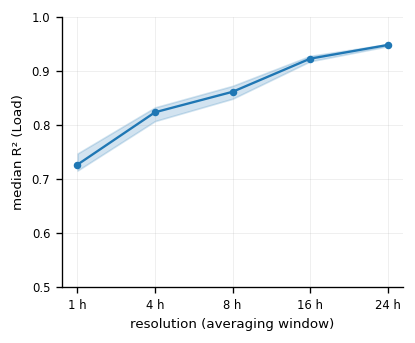

In [29]:
# Fixed (N_total, N_hp) at exactly 50 % penetration -- the largest N_total this
# design reaches -- so resolution is the only thing varying. Band is a 95 %
# percentile bootstrap CI of the median across the cell's 25 replicate
# substations, not the spread between them.
q_res = ha.quality_by_resolution(fits, 'Load', N_total=48, N_hp=24)
print(q_res.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(hf.COL1, 2.9))
x = range(len(q_res))
ax.fill_between(x, q_res.ci_lo, q_res.ci_hi, alpha=.2, color='tab:blue')
ax.plot(x, q_res.median_r2, 'o-', color='tab:blue')
ax.set_xticks(list(x)); ax.set_xticklabels(q_res.resolution)
ax.set_xlabel('resolution (averaging window)')
ax.set_ylabel('median R² (Load)')
ax.set_ylim(0.5, 1); ax.grid(alpha=.3)
fig.tight_layout()
p = hf.save(fig, 'fig_s7_quality_vs_resolution')
print('written', p + '.pdf', 'and', p + '.png')


 N_total  N_hp  n  median_r2  ci_lo  ci_hi
       4     2 25     0.8558 0.7470 0.8895
       8     4 25     0.8418 0.8207 0.8645
      12     6 25     0.9036 0.8793 0.9170
      16     8 25     0.9084 0.8916 0.9161
      20    10 25     0.9217 0.9132 0.9328
      24    12 25     0.9276 0.9142 0.9363
      28    14 25     0.9329 0.9266 0.9389
      32    16 25     0.9399 0.9343 0.9447
      36    18 25     0.9435 0.9394 0.9488
      40    20 25     0.9406 0.9349 0.9446
      44    22 25     0.9451 0.9419 0.9468
      48    24 25     0.9478 0.9454 0.9494


written paper\figures\fig_s8_quality_vs_size.pdf and paper\figures\fig_s8_quality_vs_size.png


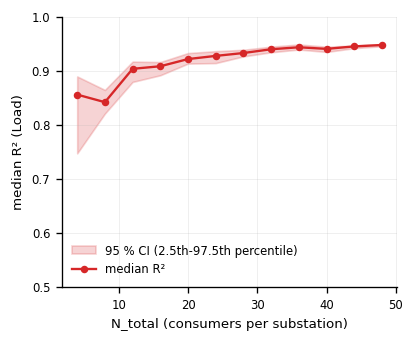

In [30]:
# Fixed resolution (24 h) and penetration ratio (50 %), across N_total. Every
# N_total in this design is a multiple of 4, so 50 % is exact everywhere --
# unlike the earlier N_hp-indexed design, no even-only filtering or reaching
# into a separate extension is needed here.
q_size = ha.quality_by_size(fits, 'Load', resolution='24 h', ratio=0.5)
print(q_size.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(hf.COL1, 2.9))
ax.fill_between(q_size.N_total, q_size.ci_lo, q_size.ci_hi, alpha=.2,
                color='tab:red', label='95 % CI (2.5th-97.5th percentile)')
ax.plot(q_size.N_total, q_size.median_r2, 'o-', color='tab:red', label='median R²')
ax.set_xlabel('N_total (consumers per substation)')
ax.set_ylabel('median R² (Load)')
ax.set_ylim(0.5, 1); ax.grid(alpha=.3); ax.legend()
fig.tight_layout()
p = hf.save(fig, 'fig_s8_quality_vs_size')
print('written', p + '.pdf', 'and', p + '.png')


In [31]:
print('logit(R²) ~ log Δt + log N_total + log N_hp   (substation random effect)')
for resp in ['Load', 'SF']:
    print(f'\n--- {resp} ---')
    print(ha.quality_model(fits, resp).round(3).to_string(index=False))
print()



logit(R²) ~ log Δt + log N_total + log N_hp   (substation random effect)

--- Load ---


   term   coef     lo     hi
 log_dt  0.598  0.593  0.603
  log_N -0.257 -0.303 -0.212
log_Nhp  0.760  0.723  0.796

--- SF ---


   term  coef    lo    hi
 log_dt 0.625 0.621 0.629
  log_N 0.089 0.049 0.129
log_Nhp 0.367 0.335 0.400



Averaging reduces the residual; how much depends on how correlated the
residuals are. If they were independent, averaging m samples would divide
the residual variance by m, so 1 - R2 would fall as 1/dt and logit(R2) would
rise by exactly one per e-fold of dt -- the benchmark alpha = 1 compared
against below.

The pooled model fits a single coefficient on log(dt). Since the relationship
is not linear in that space, the local slope between adjacent resolutions is
computed within each substation, keeping the comparison paired.


In [32]:
# Local slope between adjacent resolutions, per aggregation level.
steps = [('1 h', '4 h'), ('4 h', '8 h'), ('8 h', '16 h'), ('16 h', '24 h')]
order = pd.MultiIndex.from_tuples(steps, names=['from', 'to'])

for resp in ['Load', 'SF']:
    loc = ha.local_scaling_slopes(fits, resp)
    piv = loc.pivot_table(index='N_total', columns=['from', 'to'],
                          values='alpha').reindex(columns=order)
    print(f'{resp}: local alpha = d logit(R2) / d log(dt)')
    print(piv.round(3).to_string())
    print()


Load: local alpha = d logit(R2) / d log(dt)
from       1 h    4 h    8 h   16 h
to         4 h    8 h   16 h   24 h
N_total                            
4        0.542  0.593  0.900  0.847
8        0.446  0.536  0.773  0.735
12       0.417  0.507  0.829  0.832
16       0.385  0.468  0.827  0.913
20       0.394  0.528  0.839  0.938
24       0.378  0.456  0.959  0.996
28       0.386  0.484  0.922  0.994
32       0.373  0.449  0.928  0.994
36       0.366  0.438  0.923  0.961
40       0.366  0.451  0.896  0.979
44       0.373  0.428  0.913  0.964
48       0.373  0.422  0.914  0.979

SF: local alpha = d logit(R2) / d log(dt)
from       1 h    4 h    8 h   16 h
to         4 h    8 h   16 h   24 h
N_total                            
4        0.706  0.775  0.820  0.877
8        0.599  0.872  0.664  0.729
12       0.624  0.639  0.598  0.644
16       0.561  0.636  0.617  0.671
20       0.586  0.607  0.620  0.664
24       0.563  0.555  0.646  0.682
28       0.569  0.531  0.616  0.667
32       0.55

In [33]:
# Pooled coefficients for comparison. They are nearly identical for the two
# responses, which is exactly what the local slopes show to be misleading.
for resp in ['Load', 'SF']:
    q = ha.quality_model(fits, resp).set_index('term')
    loc = ha.local_scaling_slopes(fits, resp)
    lo = loc.groupby(['from', 'to']).alpha.median().reindex(order)
    print(f'{resp:5s} pooled log_dt = {q.loc["log_dt", "coef"]:.3f}   '
          f'local alpha by step: ' +
          '  '.join(f'{a}->{b} {v:.2f}' for (a, b), v in lo.items()))
print()
_la = ha.local_scaling_slopes(fits, 'Load').groupby(['from', 'to']).alpha.median(
    ).reindex(order)
_la_grid = ha.local_scaling_slopes(fits, 'Load').pivot_table(
    index='N_total', columns=['from', 'to'], values='alpha').reindex(columns=order)
print(f'Net load: alpha climbs from {_la.iloc[0]:.2f} at the finest step to '
      f'{_la.iloc[-1]:.2f} at the coarsest, peaking at {_la_grid.to_numpy().max():.2f}')


Load  pooled log_dt = 0.598   local alpha by step: 1 h->4 h 0.38  4 h->8 h 0.46  8 h->16 h 0.91  16 h->24 h 0.96


SF    pooled log_dt = 0.625   local alpha by step: 1 h->4 h 0.56  4 h->8 h 0.54  8 h->16 h 0.62  16 h->24 h 0.66

Net load: alpha climbs from 0.38 at the finest step to 0.96 at the coarsest, peaking at 1.00


## 5. Estimating daily thermal energy from net load

The fits so far are trained on NET load and scored against how well they
explain net load. Every substation with a heat pump also carries its own
submetered heat pump circuits, summed and integrated into a daily energy
figure independent of the fit -- so it is possible to ask a sharper
question: does the THERMAL component a net-load fit implies -- the part
attributed to the temperature deficit, not the flat base -- actually track
real heat pump energy, or does it just happen to explain net load well for
other reasons?

The estimator of a day's thermal energy (kWh) is the hockey stick's own
thermal term, `slope * max(0, T_threshold - T_mean) * 24 h`, built only from
that day's mean temperature -- exactly what the model was fitted on.

It is evaluated in-sample (the same year the parameters were fitted on), but
never against the target it was fitted on: the fit target was net load, the
comparison here is against submetered heat pump energy, which the fit never
saw.


In [34]:
# hdh_fits is not passed: the degree-hour comparison is out of scope here,
# so only the hockey stick's own thermal term is built.
est = ha.thermal_energy_estimates(design, fits)
print(f'{len(est)} substation-days, {est.substation_id.nunique()} substations')
print()
print('accuracy against submetered ground truth, every substation-day pooled:')
print(ha.thermal_energy_summary(est, by='pooled').round(4).to_string())
print()
print('same statistics computed within each substation first, then the median:')
print(ha.thermal_energy_summary(est, by='substation').round(4).to_string())


438000 substation-days, 1200 substations

accuracy against submetered ground truth, every substation-day pooled:
            r2  rmse_kWh  mae_kWh  bias_kWh  bias_pct
hs_kWh  0.9526   90.7198  64.4432  -39.7751  -11.5249

same statistics computed within each substation first, then the median:


            r2  rmse_kWh  mae_kWh  bias_kWh  bias_pct
hs_kWh  0.9185    64.549  54.6774  -29.8184  -11.9714


In [35]:
# Same accuracy statistics as above, now stratified by ETL penetration --
# checks whether Energy Estimation inherits the size-dependent confound the
# same way Detection does, or is more robust to it.
est['pen'] = est.N_hp / est.N_total
by_pen = ha.thermal_energy_summary_by(est, 'pen')
print('accuracy against submetered ground truth, by ETL penetration:')
print(by_pen.round(4).rename(index=lambda p: f'{p:.0%}').to_string())


accuracy against submetered ground truth, by ETL penetration:
          r2  rmse_kWh  mae_kWh  bias_kWh  bias_pct         n
25%   0.8851   48.9848  33.5488    2.1843    1.5976  109500.0
50%   0.9409   69.6984  52.5365  -27.6838   -9.9232  109500.0
75%   0.9475   97.2929  73.9135  -54.0573  -13.0394  109500.0
100%  0.9490  127.2676  97.7740  -79.5435  -14.4566  109500.0


In [36]:
# The bias is a total-energy statistic (mean residual / mean actual); RMSE
# gives the typical size of a single day's error instead. Whether either
# concentrates on cold days (consistent with the convexity Section 2d tested
# for) or elsewhere is a different question from whether it exists.
est['T_bin'] = pd.qcut(est.T_mean, 8)
by_temp = ha.thermal_energy_summary_by(est, 'T_bin')
print('accuracy by temperature octile (coldest to warmest):')
print(by_temp.round(2).to_string())
print()

tot = est[['actual_kWh', 'hs_kWh']].sum() / 1000
print('total annual thermal energy, all substations (MWh):')
print(tot.round(0).to_string())
print(f'the hockey stick recovers {100 * tot.hs_kWh / tot.actual_kWh:.0f} % of actual.')


accuracy by temperature octile (coldest to warmest):
                    r2  rmse_kWh  mae_kWh  bias_kWh  bias_pct        n
(-9.558, 2.22]    0.98     84.93    60.85      5.83      0.73  55104.0
(2.22, 5.841]     0.98     66.10    47.53     -3.61     -0.59  54640.0
(5.841, 7.936]    0.94     88.49    59.15    -16.11     -3.31  54784.0
(7.936, 11.225]   0.91     86.71    57.64    -40.54    -10.77  55232.0
(11.225, 14.569]  0.78     90.48    61.49    -36.15    -15.58  54816.0
(14.569, 18.352] -0.57    121.34    89.24    -88.51    -79.74  54016.0
(18.352, 20.51]  -1.61    100.27    78.72    -78.72    -99.94  55008.0
(20.51, 26.533]  -1.66     77.54    61.23    -61.23   -100.00  54400.0

total annual thermal energy, all substations (MWh):
actual_kWh    151163.0
hs_kWh        133742.0
the hockey stick recovers 88 % of actual.


In [37]:
# The octile view above is fine-grained; this collapses it to the two-sided
# comparison directly -- cold vs warm days, split at the median daily mean
# temperature across all substation-days.
est['T_half'] = np.where(est.T_mean <= est.T_mean.median(),
                         'cold (<= median)', 'warm (> median)')
by_half = ha.thermal_energy_summary_by(est, 'T_half')
print('accuracy against submetered ground truth, cold vs warm days:')
print(by_half.round(3).to_string())


accuracy against submetered ground truth, cold vs warm days:


                     r2  rmse_kWh  mae_kWh  bias_kWh  bias_pct         n
cold (<= median)  0.971    82.078   56.307   -13.642    -2.402  219760.0
warm (> median)   0.453    98.660   72.636   -66.090   -54.688  218240.0


The bias above is a total-energy statistic; RMSE, computed separately for
each substation in each season and then summarised across substations, gives
the typical size of a single day's error.


In [38]:
rmse = ha.thermal_energy_rmse_by_season(est)
print(f'{rmse.substation_id.nunique()} substations x 4 seasons = {len(rmse)} rows, '
      f'{rmse.n_days.min():.0f}-{rmse.n_days.max():.0f} days per substation-season')
print()
print('median [q25, q75] RMSE across substations, by season (kWh/day):')
rmse_summary = ha.thermal_energy_rmse_summary(rmse)
for season in ha.SEASON_ORDER:
    r = rmse_summary.loc[season]
    c = 'rmse_hs_kWh'
    print(f'  {season:8s}  {r[("q50", c)]:.0f} '
          f'[{r[("q25", c)]:.0f}, {r[("q75", c)]:.0f}]')


1200 substations x 4 seasons = 4800 rows, 90-92 days per substation-season

median [q25, q75] RMSE across substations, by season (kWh/day):
  winter    68 [37, 112]
  spring    63 [32, 107]
  summer    57 [27, 101]
  autumn    67 [34, 109]


written paper\figures\fig_s9_rmse_by_season.pdf and paper\figures\fig_s9_rmse_by_season.png


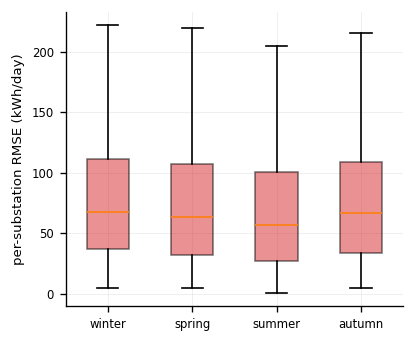

In [39]:
fig, ax = plt.subplots(figsize=(hf.COL1, 2.9))
data = [rmse.loc[rmse.season == s, 'rmse_hs_kWh'].to_numpy()
        for s in ha.SEASON_ORDER]
bp = ax.boxplot(data, positions=np.arange(len(ha.SEASON_ORDER)), widths=.5,
                patch_artist=True, showfliers=False)
for box in bp['boxes']:
    box.set_facecolor('tab:red')
    box.set_alpha(.5)
ax.set_xticks(np.arange(len(ha.SEASON_ORDER)))
ax.set_xticklabels(ha.SEASON_ORDER)
ax.set_ylabel('per-substation RMSE (kWh/day)')
ax.grid(alpha=.3, axis='y')
fig.tight_layout()
p = hf.save(fig, 'fig_s9_rmse_by_season')
print('written', p + '.pdf', 'and', p + '.png')


written paper\figures\fig_s10_example_substation_energy.pdf and paper\figures\fig_s10_example_substation_energy.png
substation 25: N_total=4, N_hp=1


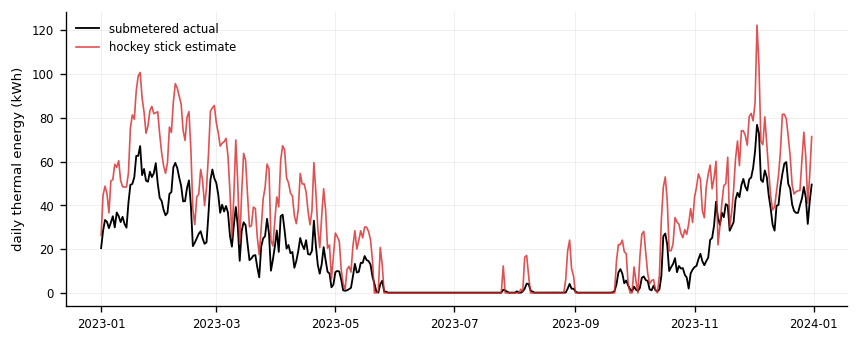

In [40]:
# One substation, illustrative: daily actual against the estimate.
example_sid = int(est.groupby('substation_id').size().idxmax())
ex = est[est.substation_id == example_sid].sort_values('date')
fig, ax = plt.subplots(figsize=(hf.COL2, 2.9))
ax.plot(ex.date, ex.actual_kWh, color='k', lw=1.1, label='submetered actual')
ax.plot(ex.date, ex.hs_kWh, color='tab:red', lw=1, alpha=.8,
        label='hockey stick estimate')
ax.set_ylabel('daily thermal energy (kWh)')
ax.grid(alpha=.3); ax.legend()
fig.tight_layout()
p = hf.save(fig, 'fig_s10_example_substation_energy')
print('written', p + '.pdf', 'and', p + '.png')
print(f'substation {example_sid}: N_total={int(ex.N_total.iloc[0])}, '
      f'N_hp={int(ex.N_hp.iloc[0])}')


### 5.4 Energy estimation by resolution

`thermal_energy_estimates` uses whichever resolution's fit (`slope`,
`T_threshold`) is passed in; every result above uses the 24 h fit. This
reruns it with the fit taken from each resolution in turn.


In [41]:
energy_by_res = []
for res in res_order:
    est_r = ha.thermal_energy_estimates(design, fits, resolution=res)
    summ = ha.thermal_energy_summary(est_r, by='pooled')
    energy_by_res.append({'resolution': res, 'n_substation_days': len(est_r),
                          'r2': summ.loc['hs_kWh', 'r2'],
                          'bias_pct': summ.loc['hs_kWh', 'bias_pct']})
energy_by_res = pd.DataFrame(energy_by_res)
print(energy_by_res.round(4).to_string(index=False))


resolution  n_substation_days     r2  bias_pct
       1 h             438000 0.9494  -13.2758
       4 h             438000 0.9496  -12.9802
       8 h             438000 0.9479  -12.9278
      16 h             438000 0.9532  -11.0524
      24 h             438000 0.9526  -11.5249


written paper\figures\fig_s11_energy_by_resolution.pdf and paper\figures\fig_s11_energy_by_resolution.png


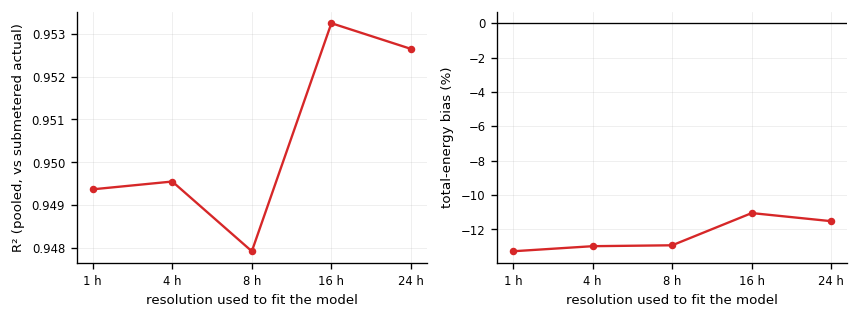

In [42]:
fig, axs = plt.subplots(1, 2, figsize=(hf.COL2, 2.7))
axs[0].plot(energy_by_res.resolution, energy_by_res.r2, 'o-', color='tab:red')
axs[0].set_xlabel('resolution used to fit the model')
axs[0].set_ylabel('R\u00b2 (pooled, vs submetered actual)')
axs[0].grid(alpha=.3)

axs[1].plot(energy_by_res.resolution, energy_by_res.bias_pct, 'o-', color='tab:red')
axs[1].axhline(0, color='k', lw=.8)
axs[1].set_xlabel('resolution used to fit the model')
axs[1].set_ylabel('total-energy bias (%)')
axs[1].grid(alpha=.3)
fig.tight_layout()
p = hf.save(fig, 'fig_s11_energy_by_resolution')
print('written', p + '.pdf', 'and', p + '.png')


### 5.1 Are the HEAPO heat pumps reversible?

A reversible heat pump running in cooling mode on hot days would put real
load on the warmest days that the heating-only model in Section 5 has no
term for. Metadata is checked first, then the submetered load itself.


In [43]:
import sys
if 'src' not in sys.path:
    sys.path.insert(0, 'src')
from heapo import HEAPO

heapo_obj = HEAPO(data_path='data/heapo_data', use_local_time=False,
                  suppress_warning=True)
heapo_meta = heapo_obj.get_meta_data_overview()
print(f'{len(heapo_meta.columns)} metadata fields:')
for c in heapo_meta.columns:
    print(' ', c)
print()
cooling_fields = [c for c in heapo_meta.columns
                 if 'cool' in c.lower() or 'revers' in c.lower()
                 or 'summer' in c.lower() or 'ac' == c.lower()]
print(f'fields mentioning cooling/reversibility/AC: {cooling_fields}')
print()
print('installation type:')
print(heapo_meta.Survey_HeatPump_Installation_Type.value_counts(dropna=False)
      .to_string())


23 metadata fields:
  Household_ID
  Group
  Weather_ID
  Installation_HasPVSystem
  Protocols_Available
  Protocols_HasMultipleVisits
  Protocols_ReportIDs
  MetaData_Available
  SmartMeterData_Available_15min
  SmartMeterData_Available_Daily
  SmartMeterData_Available_Monthly
  Survey_Building_Type
  Survey_Building_LivingArea
  Survey_Building_Residents
  Survey_HeatPump_Installation_Type
  Survey_HeatDistribution_System_FloorHeating
  Survey_HeatDistribution_System_Radiator
  Survey_DHW_Production_ByHeatPump
  Survey_DHW_Production_ByElectricWaterHeater
  Survey_DHW_Production_BySolar
  Survey_Installation_HasDryer
  Survey_Installation_HasFreezer
  Survey_Installation_HasElectricVehicle

fields mentioning cooling/reversibility/AC: []

installation type:
Survey_HeatPump_Installation_Type
air-source       778
ground-source    576
NaN               54


No field in the HEAPO survey records reversibility, a cooling mode, or
summer operation of any kind -- the survey asks about heating distribution,
domestic hot water source, and appliances. Installation type (air-source vs
ground-source) is recorded.


In [44]:
import hp_design as hd

heapo_pool = hd.build_pool(heapo_obj)  # cached; instant if already built
summer = ha.summer_hp_days(heapo_pool)
print(f'{summer.household.nunique()} submetered HEAPO heat pumps with >=60 days '
      f'of June-August coverage, {len(summer)} household-days')
print()

cool_test = ha.summer_cooling_test(summer)
sig_pos = cool_test[(cool_test.rho > 0) & (cool_test.p < 0.05)]
sig_neg = cool_test[(cool_test.rho < 0) & (cool_test.p < 0.05)]
print('Spearman correlation of summer (JJA) daily load against daily mean '
      'temperature, per household:')
print(f'  median rho: {cool_test.rho.median():+.3f}')
print(f'  significant POSITIVE (cooling-like) at p<0.05: {len(sig_pos)} of '
      f'{len(cool_test)} ({len(sig_pos) / len(cool_test):.1%})')
print(f'  significant NEGATIVE at p<0.05:                {len(sig_neg)} of '
      f'{len(cool_test)} ({len(sig_neg) / len(cool_test):.1%})')
print(f'  not significant (defined):                     '
      f'{len(cool_test) - len(sig_pos) - len(sig_neg) - cool_test.constant.sum()}')
if cool_test.constant.sum():
    print(f'  constant summer load (correlation undefined):  {cool_test.constant.sum()}')


Loading cached household pool from data/_design_pool_cache.pkl


57 submetered HEAPO heat pumps with >=60 days of June-August coverage, 5244 household-days

Spearman correlation of summer (JJA) daily load against daily mean temperature, per household:
  median rho: -0.275
  significant POSITIVE (cooling-like) at p<0.05: 2 of 57 (3.5%)
  significant NEGATIVE at p<0.05:                33 of 57 (57.9%)
  not significant (defined):                     22


median SF (load / installed peak) by June-August temperature bin, coolest to warmest:
           median  count
9.0-17.0   0.0272    875
17.0-18.9  0.0195    886
18.9-19.8  0.0182    886
19.8-21.2  0.0172    849
21.2-22.8  0.0155    884
22.8-27.0  0.0155    864


written paper\figures\fig_s12_heapo_summer_sf.pdf and paper\figures\fig_s12_heapo_summer_sf.png


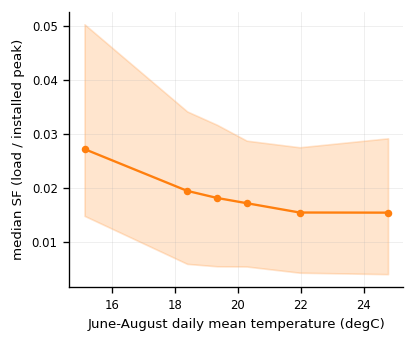

In [45]:
# Pooled across households, binned by temperature: does load turn up at the
# hot end anywhere in the distribution?
summer['T_bin'] = pd.qcut(summer['T'], 6)
by_bin = summer.groupby('T_bin', observed=True)['sf'].agg(['median', 'count'])
by_bin.index = [f'{iv.left:.1f}-{iv.right:.1f}' for iv in by_bin.index]
print('median SF (load / installed peak) by June-August temperature bin, '
      'coolest to warmest:')
print(by_bin.round(4).to_string())

fig, ax = plt.subplots(figsize=(hf.COL1, 2.9))
mid = [summer.loc[summer.T_bin == iv, 'T'].median()
      for iv in summer.T_bin.cat.categories]
med = summer.groupby('T_bin', observed=True)['sf'].median()
q25 = summer.groupby('T_bin', observed=True)['sf'].quantile(.25)
q75 = summer.groupby('T_bin', observed=True)['sf'].quantile(.75)
ax.fill_between(mid, q25, q75, alpha=.2, color='tab:orange')
ax.plot(mid, med, 'o-', color='tab:orange')
ax.set_xlabel('June-August daily mean temperature (degC)')
ax.set_ylabel('median SF (load / installed peak)')
ax.grid(alpha=.3)
fig.tight_layout()
p = hf.save(fig, 'fig_s12_heapo_summer_sf')
print('written', p + '.pdf', 'and', p + '.png')


### 5.2 Are the WPUQ heat pumps reversible?

WPUQ carries no survey or installation metadata -- the HDF5 file's structure
was checked directly: two top-level household groups (`NO_PV`, `WITH_PV`),
each household holding only `HEATPUMP` and `HOUSEHOLD` power series, plus a
`MISC` group for the transformer and PV plant. The same load-based test used
for HEAPO applies directly, covering the full 37 households.


In [46]:
wpuq_pool = hpp.build_pool_wpuq(verbose=False)
wpuq_summer = ha.summer_hp_days(wpuq_pool)
print(f'{wpuq_summer.household.nunique()} of {len(wpuq_pool["hp_households"])} '
      f'WPUQ heat pumps with >=60 days of June-August coverage, '
      f'{len(wpuq_summer)} household-days')
print()

wpuq_cool_test = ha.summer_cooling_test(wpuq_summer)
sig_pos = wpuq_cool_test[(wpuq_cool_test.rho > 0) & (wpuq_cool_test.p < 0.05)]
sig_neg = wpuq_cool_test[(wpuq_cool_test.rho < 0) & (wpuq_cool_test.p < 0.05)]
print(f'  median rho: {wpuq_cool_test.rho.median():+.3f}')
print(f'  significant POSITIVE (cooling-like) at p<0.05: {len(sig_pos)} of '
      f'{len(wpuq_cool_test)} ({len(sig_pos) / len(wpuq_cool_test):.1%})')
print(f'  significant NEGATIVE at p<0.05:                {len(sig_neg)} of '
      f'{len(wpuq_cool_test)} ({len(sig_neg) / len(wpuq_cool_test):.1%})')
print(f'  not significant (defined):                     '
      f'{len(wpuq_cool_test) - len(sig_pos) - len(sig_neg) - wpuq_cool_test.constant.sum()}')
if wpuq_cool_test.constant.sum():
    print(f'  constant summer load (correlation undefined):  {wpuq_cool_test.constant.sum()}')


37 of 37 WPUQ heat pumps with >=60 days of June-August coverage, 3404 household-days

  median rho: -0.182
  significant POSITIVE (cooling-like) at p<0.05: 2 of 37 (5.4%)
  significant NEGATIVE at p<0.05:                18 of 37 (48.6%)
  not significant (defined):                     16
  constant summer load (correlation undefined):  1


median SF by June-August temperature bin, coolest to warmest:
           median  count
12.9-16.3  0.0067    592
16.3-17.9  0.0047    555
17.9-19.3  0.0047    555
19.3-20.3  0.0035    592
20.3-23.0  0.0032    555
23.0-28.2  0.0033    555



written paper\figures\fig_s13_wpuq_summer_sf.pdf and paper\figures\fig_s13_wpuq_summer_sf.png


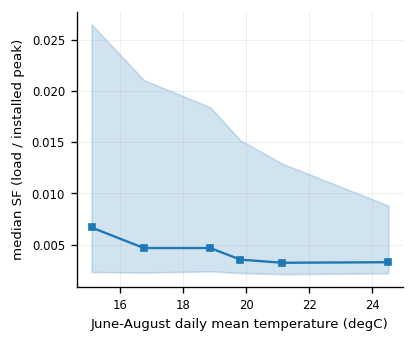

In [47]:
wpuq_summer['T_bin'] = pd.qcut(wpuq_summer['T'], 6)
by_bin_de = wpuq_summer.groupby('T_bin', observed=True)['sf'].agg(['median', 'count'])
by_bin_de.index = [f'{iv.left:.1f}-{iv.right:.1f}' for iv in by_bin_de.index]
print('median SF by June-August temperature bin, coolest to warmest:')
print(by_bin_de.round(4).to_string())
print()

fig, ax = plt.subplots(figsize=(hf.COL1, 2.9))
mid = [wpuq_summer.loc[wpuq_summer.T_bin == iv, 'T'].median()
      for iv in wpuq_summer.T_bin.cat.categories]
med = wpuq_summer.groupby('T_bin', observed=True)['sf'].median()
q25 = wpuq_summer.groupby('T_bin', observed=True)['sf'].quantile(.25)
q75 = wpuq_summer.groupby('T_bin', observed=True)['sf'].quantile(.75)
ax.fill_between(mid, q25, q75, alpha=.2, color='tab:blue')
ax.plot(mid, med, 's-', color='tab:blue')
ax.set_xlabel('June-August daily mean temperature (degC)')
ax.set_ylabel('median SF (load / installed peak)')
ax.grid(alpha=.3)
fig.tight_layout()
p = hf.save(fig, 'fig_s13_wpuq_summer_sf')
print('written', p + '.pdf', 'and', p + '.png')


### 5.3 A known-cooling ground truth (Pecan Street, Austin)

A test for reversibility is only useful if it can detect a cooling signature
when one is actually present. This section checks that directly, using
equipment that is unambiguously cooling-only.

Pecan Street's Dataport panel submeters central AC (`air1`/`air2`/`air3`)
directly for a subset of Austin, Texas households. The metadata file covers
Pecan Street's whole panel (Ithaca NY, Detroit, Houston, Boulder and others
share the same download despite the folder name), so every household used
below is filtered on `city == 'Austin', state == 'Texas'` explicitly.
Whole-home consumption is reconstructed by summing every appliance circuit
except `grid`/`solar`, so PV feed-in cannot net the load negative the way
the raw `grid` column does on sunny days. Only one calendar year (2018) is
available, and only 22 of 25 AC-flagged households pass a basic quality
check (`pecan_street.load_austin_ac_pool`) -- one has clearly corrupted
circuit readings, one has no real `air1` data despite the metadata flag, one
reconstructs too far from its own whole-home meter to trust.

This is a fixed, small pool, not a ratio-grid design like the substation
study above: Austin homes overwhelmingly have central AC, so there is no
comparably-sized non-AC population to draw a penetration grid from.


In [48]:
import pecan_street as ps

pecan_daily, pecan_qc = ps.load_austin_ac_pool()

# Same test as 5.1/5.2, same statistic, on known-cooling equipment: does
# the load turn up with heat in June-August?
pecan_summer_frames = []
for dataid, d in pecan_daily.items():
    jja = d[d.index.month.isin([6, 7, 8])].copy()
    if len(jja) < 60:
        continue
    jja['household'] = dataid
    pecan_summer_frames.append(jja)
pecan_summer = pd.concat(pecan_summer_frames)

pecan_cool_test = ha.summer_cooling_test(pecan_summer)
sig_pos = pecan_cool_test[(pecan_cool_test.rho > 0) & (pecan_cool_test.p < 0.05)]
sig_neg = pecan_cool_test[(pecan_cool_test.rho < 0) & (pecan_cool_test.p < 0.05)]
print(f'{pecan_summer.household.nunique()} usable Austin AC households with >=60 '
      f'days of June-August coverage, {len(pecan_summer)} household-days')
print()
print(f'  median rho: {pecan_cool_test.rho.median():+.3f}')
print(f'  significant POSITIVE (cooling-like) at p<0.05: {len(sig_pos)} of '
      f'{len(pecan_cool_test)} ({len(sig_pos) / len(pecan_cool_test):.1%})')
print(f'  significant NEGATIVE at p<0.05:                {len(sig_neg)} of '
      f'{len(pecan_cool_test)} ({len(sig_neg) / len(pecan_cool_test):.1%})')


25 Austin, Texas households flagged for AC in metadata; 22 usable after QC (3 dropped)


22 usable Austin AC households with >=60 days of June-August coverage, 2010 household-days

  median rho: +0.638
  significant POSITIVE (cooling-like) at p<0.05: 21 of 22 (95.5%)
  significant NEGATIVE at p<0.05:                0 of 22 (0.0%)


per-household fit quality, 22 homes, R2 0.00-0.95:
 dataid  base  slope  T_balance    r2   n
   2818 0.325  0.241     20.484 0.955 365
   7536 0.377  0.197     21.230 0.926 365
   5746 0.318  0.156     21.656 0.926 363
   9160 0.166  0.148     20.760 0.900 365
   3456 0.415  0.129     22.204 0.896 365
   2335 0.398  0.175     20.642 0.888 360
   7800 0.598  0.126     20.551 0.874 365
   7719 0.602  0.172     19.654 0.845 365
   3538 0.286  0.116     22.145 0.829 365
   4373 0.810  0.202     20.840 0.820 361
    661 0.421  0.179     21.920 0.805 365
   8156 0.722  0.202     16.553 0.803 365
   7901 0.623  0.127     19.833 0.784 365
   3039 0.589  0.096     15.000 0.748 365
   4767 0.622  0.279     21.430 0.710 365
   8565 0.679  0.076     15.000 0.656 365
   6139 1.016  0.191     23.865 0.655 365
   1642 0.680  0.099     17.530 0.654 362
   8386 0.438  0.082     22.754 0.603 365
   7951 0.636  0.171     24.610 0.501 365
   9278 0.986  0.145     23.113 0.227 365
   9922 1.783  0.049     

'paper\\figures\\fig_hockey_stick_cooling_example'

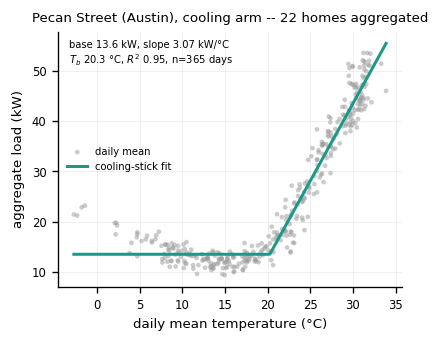

In [49]:
# Whole-home consumption is additive across the pool the same way substation
# load is: per-household fit quality first, then sum every usable household
# before fitting the aggregate. The kink sits above the balance temperature
# (AC turning on), not below it -- the same three-parameter model and
# fitting machinery as the heating study, mirrored in direction.
from hp_common import fit_cooling_stick

pecan_fits = []
for dataid, d in pecan_daily.items():
    base, slope, tbal, r2 = fit_cooling_stick(d['T'].to_numpy(), d['load'].to_numpy())
    pecan_fits.append({'dataid': dataid, 'base': base, 'slope': slope,
                       'T_balance': tbal, 'r2': r2, 'n': len(d)})
pecan_fits = pd.DataFrame(pecan_fits).sort_values('r2', ascending=False)
print(f'per-household fit quality, {len(pecan_fits)} homes, '
      f'R2 {pecan_fits.r2.min():.2f}-{pecan_fits.r2.max():.2f}:')
print(pecan_fits.round(3).to_string(index=False))
print()

pecan_agg_load = None
for d in pecan_daily.values():
    pecan_agg_load = (d['load'].copy() if pecan_agg_load is None
                      else pecan_agg_load.add(d['load'], fill_value=0))
pecan_agg_T = ps.load_austin_temperature()
hf.fig_cooling_stick_example(pecan_agg_T, pecan_agg_load, n_homes=len(pecan_daily))


Pecan Street's metadata has no HVAC-type survey field -- circuit presence is
the only signal available. `furnace1` (Pecan Street's air-handler/blower
circuit, present on both electric-furnace and heat-pump systems, and
carrying any electric resistance backup heat those systems have) is
submetered on 21 of the 22 usable households, `furnace2` on 2, and no
household has a dedicated `heater1/2/3`. A bathtub fit
(`hp_common.fit_bathtub_stick`: two hockey sticks sharing one base load,
joined by a deadband) is fitted to check the cold end directly.


In [50]:
# No HVAC-type survey field exists in this metadata beyond circuit
# presence flags -- checked directly rather than assumed absent.
meta_cols = pd.read_csv('data/15minute_data_austin/metadata.csv', skiprows=[1]).columns
circuit_flags = {'furnace1', 'furnace2', 'heater1', 'heater2', 'heater3',
                 'waterheater1', 'waterheater2'}
heat_fields = [c for c in meta_cols if any(k in c.lower() for k in
              ('heat', 'furnace', 'hvac', 'thermostat')) and c not in circuit_flags]
print(f'metadata fields naming heating/HVAC beyond circuit flags: {heat_fields or "none"}')
print()

pecan_meta_all = pd.read_csv('data/15minute_data_austin/metadata.csv', skiprows=[1])
pecan_meta_all['dataid'] = pd.to_numeric(pecan_meta_all['dataid'], errors='coerce')
usable_meta = pecan_meta_all[pecan_meta_all.dataid.isin(pecan_daily.keys())]
for c in ['furnace1', 'furnace2', 'heater1', 'heater2', 'heater3']:
    print(f'  {c} flagged: {(usable_meta[c] == "yes").sum()} of {len(usable_meta)}')
print()

# Does the AC compressor circuit itself run harder in winter (a reversible
# heat pump), the air-handler circuit (blower load, present on every
# heating AND cooling cycle, plus any resistance backup heat), or both?
pecan_ac_only = ps.circuit_daily_aggregate(list(pecan_daily.keys()), ['air1', 'air2', 'air3'])
pecan_furnace_only = ps.circuit_daily_aggregate(list(pecan_daily.keys()), ['furnace1', 'furnace2'])
comp = pd.DataFrame({'T': pecan_agg_T, 'ac': pecan_ac_only,
                     'furnace': pecan_furnace_only}).dropna()
for label, col in [('air1/2/3 (compressor)', 'ac'), ('furnace1/2 (air handler)', 'furnace')]:
    cold = comp.loc[comp['T'] < 5, col].median()
    mild = comp.loc[(comp['T'] > 15) & (comp['T'] < 20), col].median()
    hot = comp.loc[comp['T'] > 30, col].median()
    print(f'{label}: median {cold:.2f} kW below 5 degC, {mild:.2f} kW at '
          f'15-20 degC, {hot:.2f} kW above 30 degC')


metadata fields naming heating/HVAC beyond circuit flags: none

  furnace1 flagged: 21 of 22
  furnace2 flagged: 2 of 22
  heater1 flagged: 0 of 22
  heater2 flagged: 0 of 22
  heater3 flagged: 0 of 22



air1/2/3 (compressor): median 2.06 kW below 5 degC, 1.20 kW at 15-20 degC, 29.58 kW above 30 degC
furnace1/2 (air handler): median 5.61 kW below 5 degC, 1.46 kW at 15-20 degC, 7.68 kW above 30 degC


'paper\\figures\\fig_bathtub_example'

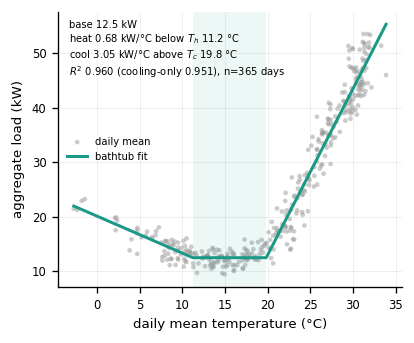

In [51]:
hf.fig_bathtub_example(pecan_agg_T, pecan_agg_load, n_homes=len(pecan_daily))


Real feeders are not a uniform household draw: households on one feeder
share building age and construction type, and heat pumps tend to arrive in
installation cohorts. This section compares a clustered (house-only) draw
against the random draw used everywhere else.

The combined pool has dwelling category for every household, the only
composition variable present for both cohorts -- heat pump vintage, model
and control strategy are not recorded in either dataset. Of the 81
submetered heat pumps, 80 are in houses and one is in an apartment, so an
apartment-clustered arm with heat pumps in it does not exist. The clustered
arm is therefore house-only substations, compared against the random draw,
which is about four fifths apartments.


In [52]:
CLUSTER_DESIGN = 'data/design_clustered.pkl'
CLUSTER_FITS = 'data/clustered_fits.parquet'
REGENERATE_CLUSTER = False

if REGENERATE_CLUSTER:
    pool_all = hpp.build_pool_combined(verbose=False)
    groups = hpp.dwelling_groups(pool_all)
    print(groups.value_counts().to_string())
    houses = [h for h in pool_all['households'] if groups[h] == 'house']
    pool_house = hpp.restrict_pool(pool_all, houses)
    design_cl, cov_cl = hd.generate_design(
        pool_house, n_grid=N_TOTAL_GRID, ratio_grid=RATIO_GRID,
        n_reps=25, eheat_frac=0.0, clean_hp=False, seed=42, verbose=False)
    hd.save_design(design_cl, CLUSTER_DESIGN)
    cluster_fits = ha.fit_all(design_cl, verbose=False)
    cluster_fits.to_parquet(CLUSTER_FITS)
else:
    design_cl = hd.load_design(CLUSTER_DESIGN)
    cluster_fits = pd.read_parquet(CLUSTER_FITS)

print(f'clustered arm: {len(design_cl["meta"])} substations from '
      f'{design_cl["n_distinct_households_used"]} houses')


clustered arm: 1500 substations from 169 houses


In [53]:
# Same grid, same fits, only the composition of the draw differs. The
# houses-only pool (80 heat pump houses) still supports every cell up to
# N_total=48, so both arms cover exactly the same range -- no restriction to a
# shared subset is needed here.
assert set(design['meta'].N_total) == set(design_cl['meta'].N_total)

rows = []
for nm, F, D in [('random', fits, design), ('clustered', cluster_fits, design_cl)]:
    sf = F[(F.response == 'SF') & (F.resolution == '24 h') & (~F.failed)]
    ld = F[(F.response == 'Load') & (F.resolution == '24 h') & (~F.failed)]
    det = ha.detection_threshold(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    _, auc = ha.roc(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    r = det['by_hp_ratio']
    reached = r[r > 0.8]
    rows.append({'arm': nm, 'n_sf': len(sf),
                 'SF_at_coldest': ha.sf_at_coldest(F[F.response == 'SF']).median(),
                 'SF_slope': sf.slope.median(),
                 'Load_slope': ld.slope.median(),
                 'auc': auc, 'sensitivity': det['sensitivity'],
                 'first_ratio_over_80': (reached.index[0] if len(reached) else 'none')})
print(pd.DataFrame(rows).round(4).to_string(index=False))
print()
print('detection rate by penetration:')
for nm, F in [('random', fits), ('clustered', cluster_fits)]:
    det = ha.detection_threshold(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    print(f'  {nm:10s} ' + '  '.join(f'{r:.0%}={v:.2f}'
                                     for r, v in det['by_hp_ratio'].items()))


      arm  n_sf  SF_at_coldest  SF_slope  Load_slope    auc  sensitivity  first_ratio_over_80
   random  1200         0.4210    0.0160      1.2581 0.9895       0.9583                 0.25
clustered  1200         0.4282    0.0163      1.7391 0.9041       0.5875                 1.00

detection rate by penetration:
  random     25%=0.87  50%=0.97  75%=1.00  100%=1.00
  clustered  25%=0.16  50%=0.48  75%=0.78  100%=0.93


WPUQ is 38 German single-family houses on one low-voltage feeder, each with
separately metered heat pump and household circuits, for calendar 2019.

The temperature series is recorded every five minutes; the Swiss series is
hourly. The coarsest step used anywhere in this analysis is one hour, so
every resolution here rests on genuine hourly temperature in both datasets.

The data is from 2019, before German provisions for controllable heat pump
loads came into force in 2024.

The feeder also has a measured transformer, allowing synthetic aggregation
to be compared against a real one.


In [54]:
WPUQ_DESIGN = 'data/design_wpuq_val.pkl'
WPUQ_FITS = 'data/wpuq_val_fits.parquet'
REGENERATE_WPUQ = False

if REGENERATE_WPUQ:
    wpuq_pool = hpp.build_pool_wpuq(rebuild=REBUILD_POOL)
    # the same ratio grid as Switzerland, capped at N_total=36 (37 households,
    # all with heat pumps, largest multiple of 4 the pool supports)
    wpuq_design, _ = hd.generate_design(
        wpuq_pool, n_grid=list(range(4, 37, 4)), ratio_grid=RATIO_GRID,
        # the same rule, though it is a no-op here: WPUQ carries no appliance
        # metadata, so nothing is flagged and the draw is unchanged. Its
        # controls are clean by construction anyway, being metered houses
        # with the heat pump circuit omitted.
        n_reps=40, eheat_frac=0.0, clean_hp=False, seed=42, verbose=False)
    hd.save_design(wpuq_design, WPUQ_DESIGN)
    wpuq_fits = ha.fit_all(wpuq_design, verbose=False)
    wpuq_fits.to_parquet(WPUQ_FITS)
else:
    wpuq_pool = hpp.build_pool_wpuq(verbose=False)
    wpuq_design = hd.load_design(WPUQ_DESIGN)
    wpuq_fits = pd.read_parquet(WPUQ_FITS)

wpuq_load = wpuq_fits[wpuq_fits.response == 'Load']
wpuq_sf = wpuq_fits[wpuq_fits.response == 'SF']
print(f'{len(wpuq_design["meta"])} substations from '
      f'{wpuq_design["n_distinct_households_used"]} households, all with heat pumps')


1800 substations from 37 households, all with heat pumps


### 5.6 Nested aggregation on WPUQ

The factorial WPUQ design above answers a grid question and reuses the same 37
houses across 1800 substations. The paper's Section IV no longer makes a grid
claim: it reproduces one result, that fit quality improves as consumers are
added, and for that a nested sequence is both smaller and stronger.

One substation per aggregation level, each containing the one below it, so a
step from N to N+4 is literally four consumers added to a fixed aggregate
rather than an independent redraw. Roles are fixed before any aggregate is
built, so penetration stays at 50 % throughout. No replicates, and none
implied -- a single realisation, read as a direction rather than a rate.


In [55]:
import hp_nested as hn

nested_levels = hn.nested_levels(wpuq_pool, step=4, penetration=0.5, seed=42)
print(f'{len(nested_levels)} nested substations: '
      f'N = {[n for n, _, _ in nested_levels]}')
_prev = set()
for _n, _m, _hp in nested_levels:
    assert _prev <= set(_m), f'not nested at N={_n}'
    _prev = set(_m)
print('nesting verified: every level contains the one below it')
print()

nested_fits = hn.fit_levels(wpuq_pool, nested_levels)
piv = nested_fits.pivot(index='N_total', columns='resolution',
                        values='r2')[hn.RESOLUTIONS]
print('net-load R2 by aggregation level and averaging window:')
print(piv.round(3).to_string())
print()
for res in ['1 h', '24 h']:
    lo, hi = piv[res].iloc[0], piv[res].iloc[-1]
    print(f'  {res:5s}  N=4 -> N=36:  {lo:.3f} -> {hi:.3f}  (+{hi - lo:.3f})')


9 nested substations: N = [4, 8, 12, 16, 20, 24, 28, 32, 36]
nesting verified: every level contains the one below it



net-load R2 by aggregation level and averaging window:
resolution    1 h    4 h    8 h   16 h   24 h
N_total                                      
4           0.499  0.570  0.608  0.653  0.667
8           0.539  0.586  0.622  0.680  0.696
12          0.565  0.601  0.632  0.697  0.715
16          0.556  0.596  0.635  0.713  0.735
20          0.591  0.632  0.679  0.767  0.794
24          0.602  0.642  0.691  0.787  0.817
28          0.615  0.654  0.708  0.808  0.839
32          0.598  0.639  0.708  0.821  0.859
36          0.605  0.641  0.704  0.811  0.845

  1 h    N=4 -> N=36:  0.499 -> 0.605  (+0.106)
  24 h   N=4 -> N=36:  0.667 -> 0.845  (+0.178)


### 5.5 Energy estimation, WPUQ

The same thermal-energy check as Section 5, now against WPUQ's own submetered
heat pump circuits, with no refitting: the hockey-stick parameters used below
are the ones already fitted on WPUQ net load in the cell above.


In [56]:
wpuq_est = ha.thermal_energy_estimates(wpuq_design, wpuq_fits)
print(f'{len(wpuq_est)} substation-days, {wpuq_est.substation_id.nunique()} substations')
print()
print('accuracy against submetered ground truth, WPUQ, every substation-day pooled:')
print(ha.thermal_energy_summary(wpuq_est, by='pooled').round(4).to_string())
print()
wpuq_est['pen'] = wpuq_est.N_hp / wpuq_est.N_total
by_pen_de = ha.thermal_energy_summary_by(wpuq_est, 'pen')
print('accuracy against submetered ground truth, WPUQ, by ETL penetration:')
print(by_pen_de.round(4).rename(index=lambda p: f'{p:.0%}').to_string())


525600 substation-days, 1440 substations

accuracy against submetered ground truth, WPUQ, every substation-day pooled:
            r2  rmse_kWh  mae_kWh  bias_kWh  bias_pct
hs_kWh  0.8549   88.1901  55.2942  -15.6776   -9.1768

accuracy against submetered ground truth, WPUQ, by ETL penetration:
          r2  rmse_kWh  mae_kWh  bias_kWh  bias_pct         n
25%   0.7742   39.6724  26.4601    8.7361   12.6819  131400.0
50%   0.8369   65.2633  43.8578   -8.1061   -5.9318  131400.0
75%   0.8413   95.5034  64.7093  -24.0332  -11.6895  131400.0
100%  0.8397  127.1057  86.1494  -39.3073  -14.4395  131400.0


In [57]:
# Cold vs warm split, WPUQ -- same construction as the Swiss T_half cell above,
# checking whether the dead-band warm-day underestimation also shows up here.
wpuq_est['T_half'] = np.where(wpuq_est.T_mean <= wpuq_est.T_mean.median(),
                              'cold (<= median)', 'warm (> median)')
by_half_de = ha.thermal_energy_summary_by(wpuq_est, 'T_half')
print('accuracy against submetered ground truth, WPUQ, cold vs warm days:')
print(by_half_de.round(3).to_string())


accuracy against submetered ground truth, WPUQ, cold vs warm days:
                     r2  rmse_kWh  mae_kWh  bias_kWh  bias_pct         n
cold (<= median)  0.828   113.637   74.316     0.289     0.100  263520.0
warm (> median)   0.181    51.122   36.167   -31.732   -62.075  262080.0


In [58]:
# The measured transformer on the same feeder. Comparing it against the sum of
# the monitored households says how much of a real feeder the monitored set
# actually represents.
import h5py

widx = wpuq_pool['index']
wT = pd.Series(wpuq_pool['temperature']['WPUQ'], index=widx)
with h5py.File('data/2019_data_15min.hdf5', 'r') as _h:
    _t = _h['MISC']['ES1']['TRANSFORMER']['table'][:]
transformer = pd.Series(_t['P_TOT'] / 1000,
                        index=pd.to_datetime(_t['index'], unit='s', utc=True)).sort_index()
transformer = transformer[~transformer.index.duplicated()].reindex(widx).interpolate().clip(lower=0)

mon_hp = pd.Series(wpuq_pool['hp_mat'].sum(axis=0), index=widx)
mon_tot = mon_hp + pd.Series(wpuq_pool['other_mat'].sum(axis=0), index=widx)
hp_peak_total = float(wpuq_pool['hp_peak'].sum())

print(f'transformer            mean {transformer.mean():6.1f} kW  peak {transformer.max():6.1f} kW')
print(f'monitored households   mean {mon_tot.mean():6.1f} kW  peak {mon_tot.max():6.1f} kW')
print(f'monitored share of the real feeder: {100 * mon_tot.mean() / transformer.mean():.1f}%')
print(f'shape correlation: {np.corrcoef(transformer.values, mon_tot.values)[0, 1]:.3f}')


transformer            mean   68.4 kW  peak  261.7 kW
monitored households   mean   33.8 kW  peak  141.5 kW
monitored share of the real feeder: 49.5%
shape correlation: 0.952


In [59]:
# Does random subsampling distort simultaneity? The real 37-household aggregate
# is one known realisation to compare the synthetic distribution against.
dreal = pd.DataFrame({'T': wT.resample('D').mean(),
                      'y': (mon_hp / hp_peak_total).resample('D').mean()}).dropna()
rb, rs, rt, rr2 = hockey_stick_fit = __import__('hp_common').fit_hockey_stick(
    dreal['T'].to_numpy(), dreal['y'].to_numpy(), T_BALANCE_BOUNDS)
sf_real = rb + rs * max(0.0, rt - dreal['T'].min())
print(f'real 37-household aggregate: SF slope {rs:.4f}/degC, threshold {rt:.2f} degC, '
      f'SF at coldest ({dreal["T"].min():.1f} degC) = {sf_real:.3f}')

wsf = wpuq_sf[(wpuq_sf.resolution == '24 h') & (~wpuq_sf.failed)].copy()
wsf['sf_cold'] = wsf.base + wsf.slope * np.maximum(0, wsf.T_threshold - wsf.T_min_obs)
print()
print('synthetic SF at coldest observed, by heat-pump count:')
print(wsf.groupby('N_hp').sf_cold.median().round(3).to_string())
print()



real 37-household aggregate: SF slope 0.0133/degC, threshold 13.27 degC, SF at coldest (-5.4 degC) = 0.266

synthetic SF at coldest observed, by heat-pump count:
N_hp
1     0.239
2     0.292
3     0.266
4     0.271
5     0.265
6     0.267
7     0.244
8     0.262
9     0.273
10    0.256
12    0.263
14    0.278
15    0.251
16    0.264
18    0.265
20    0.268
21    0.263
24    0.265
27    0.265
28    0.266
32    0.270
36    0.267



In [60]:
# The strongest available test: apply the Swiss threshold to real measured
# aggregates, with no recalibration.
from hp_common import fit_hockey_stick

thr_swiss = ha.detection_threshold(load_fits, 'slope_per_peak', '24 h')['threshold']
print(f'Swiss threshold: {thr_swiss:.4f} 1/degC')
for nm, series in [('ES1 transformer (real feeder, half unmonitored)', transformer),
                   ('monitored households only', mon_tot)]:
    dd = pd.DataFrame({'T': wT.resample('D').mean(),
                       'y': series.resample('D').mean()}).dropna()
    _, ss, _, _ = fit_hockey_stick(dd['T'].to_numpy(), dd['y'].to_numpy(), T_BALANCE_BOUNDS)
    pk = float(series.resample('D').mean().max())
    flag = 'detected' if ss / pk >= thr_swiss else 'missed'
    print(f'  {nm:46s} slope/peak {ss / pk:.4f}  {flag}')


Swiss threshold: 0.0218 1/degC
  ES1 transformer (real feeder, half unmonitored) slope/peak 0.0386  detected
  monitored households only                      slope/peak 0.0365  detected


In [61]:
# Both datasets at the SAME operating point, the one calibrated on Switzerland.
# Scoring each dataset at its own 95th percentile would tie the threshold to how
# clean that dataset's heat-pump-free group happens to be, and WPUQ's is
# synthetic, so its own threshold comes out lower than the Swiss value.
det_ch24 = ha.detection_threshold(load_fits, 'slope_per_peak', '24 h')
thr_ch24 = det_ch24['threshold']
det_de24 = ha.detection_at(wpuq_load, thr_ch24)

print(f'threshold calibrated on Switzerland: {thr_ch24:.4f} 1/degC')
print(f"  Switzerland  sensitivity {det_ch24['sensitivity']:.3f}  "
      f"false positives {det_ch24['observed_fpr']:.3f}")
print(f"  Germany      sensitivity {det_de24['sensitivity']:.3f}  "
      f"false positives {det_de24['observed_fpr']:.3f}")
print()
print('detection by penetration:')
for lab, det in [('Switzerland', det_ch24), ('Germany', det_de24)]:
    print(f'  {lab:12s} ' + '  '.join(f'{r:.0%}={v:.2f}'
                                      for r, v in det['by_hp_ratio'].items()))
print()
det_own = ha.detection_threshold(wpuq_load, 'slope_per_peak', '24 h')
print(f"WPUQ on its own threshold ({det_own['threshold']:.4f}) would read "
      f"{det_own['sensitivity']:.3f} overall.")



threshold calibrated on Switzerland: 0.0218 1/degC
  Switzerland  sensitivity 0.958  false positives 0.050
  Germany      sensitivity 0.970  false positives 0.000

detection by penetration:
  Switzerland  25%=0.87  50%=0.97  75%=1.00  100%=1.00
  Germany      25%=0.90  50%=0.98  75%=1.00  100%=1.00

WPUQ on its own threshold (0.0127) would read 0.999 overall.


In [62]:
# Every headline number, Switzerland against Germany.
def _headline(F, D, label):
    ld = F[(F.response == 'Load') & (F.resolution == '24 h') & (~F.failed)]
    sf = F[(F.response == 'SF') & (F.resolution == '24 h') & (~F.failed)]
    env, rng = ha.flexibility_envelope(F[F.response == 'SF'], D)
    det = ha.detection_threshold(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    _, auc = ha.roc(F[F.response == 'Load'], 'slope_per_peak', '24 h')
    r = det['by_hp_ratio']; reached = r[r > 0.8]
    loc = ha.local_scaling_slopes(F, 'Load')
    return pd.Series({
        'substations': len(D['meta']),
        'households used': D['n_distinct_households_used'],
        'HP households used': len({h for hh in D['meta']['hp_households'] for h in hh}),
        'slope, no HP (kW/K)': ld[ld.N_hp == 0].slope.median(),
        'slope, with HP (kW/K)': ld[ld.N_hp > 0].slope.median(),
        'load threshold T (C)': ld.T_threshold.median(),
        'SF slope (1/K)': sf.slope.median(),
        'SF threshold T (C)': sf.T_threshold.median(),
        'SF at coldest observed': ha.sf_at_coldest(F[F.response == 'SF']).median(),
        'observed T min (C)': rng[0],
        'AUC (slope/peak)': auc,
        'first ratio over 80%': (f'{reached.index[0]:.0%}' if len(reached) else 'none'),
        'alpha 1-4 h': loc[(loc['from'] == '1 h')].alpha.median(),
        'alpha 16-24 h': loc[(loc['from'] == '16 h')].alpha.median(),
    }, name=label)

two_col = pd.concat([_headline(fits, design, 'Switzerland'),
                     _headline(wpuq_fits, wpuq_design, 'Germany')], axis=1)
print(two_col.round(4).to_string())


                       Switzerland    Germany
substations                   1500       1800
households used               1384         37
HP households used              77         37
slope, no HP (kW/K)       0.122198   0.097345
slope, with HP (kW/K)     1.681266   1.058964
load threshold T (C)     16.638294  14.706393
SF slope (1/K)            0.015975   0.013416
SF threshold T (C)       16.438904  13.267942
SF at coldest observed    0.420982   0.265962
observed T min (C)       -9.556771  -5.398958
AUC (slope/peak)          0.989517   0.999257
first ratio over 80%           25%        25%
alpha 1-4 h               0.381523   0.136654
alpha 16-24 h             0.962246   0.546691


The seven figures for the manuscript are written to the figures directory as
PDF and PNG at 300 dpi. They are sized for single column width and carry no
titles, since captions belong in the paper. Switzerland is shown in blue with
circular markers and Germany in orange with square markers throughout.


### 5.7 Nested aggregation on Austin (cooling arm)

Pecan Street Austin is the one pool with a real cooling load, so it tests the
aggregation claim on the other arm of the model and on a different technology.

Circuit-level check first: only 1 of the 22 dwellings runs its air conditioner
in reverse for heating, and the furnace circuits carry a median 0.08 kW per
dwelling in the cold -- blower, not resistance heat. The heating arm of the
Austin bathtub is therefore NOT an ETL, and only the cooling arm is.

Nested the same way as WPUQ, but with no penetration to hold fixed (every
dwelling has AC) and both arms of the model free.


In [63]:
import pecan_street as ps

# Native 15-minute consumption, so the aggregate can be re-averaged at every
# window like the substation datasets, and hourly temperature.
austin_sub, austin_T, austin_qc = ps.load_austin_ac_subdaily(verbose=True)
austin_levels = hn.nested_levels_flat(sorted(austin_sub), step=2, start=4)
_prev = set()
for _n, _m in austin_levels:
    assert _prev <= set(_m), f'not nested at N={_n}'
    _prev = set(_m)
print(f'{len(austin_levels)} nested aggregates, N = '
      f'{[n for n, _ in austin_levels]}; nesting verified')
print()

# Both arms free, at every averaging window.
austin_nested = hn.fit_levels_bathtub_multires(austin_sub, austin_T, austin_levels)
_piv = austin_nested.pivot(index="N_total", columns="resolution", values="r2")[hn.RESOLUTIONS]
print("net-load R2 by aggregation level and averaging window:")
print(_piv.round(3).to_string())
print()
_d24 = austin_nested[austin_nested.resolution == "24 h"]
_hi = _d24[_d24.N_total >= 10]
print(f"24 h R2: {_d24.r2.iloc[0]:.3f} -> {_d24.r2.iloc[-1]:.3f}")
print(f"threshold sd over N>=10, 24 h:  T_cool {_hi.T_cool.std():.3f} degC "
      f"(the real ETL arm),  T_heat {_hi.T_heat.std():.3f} degC (not an ETL)")
print(f"consumer gain (N=4->22) by window: "
      + "  ".join(f'{r}={_piv[r].iloc[-1]-_piv[r].iloc[0]:+.3f}' for r in hn.RESOLUTIONS))


25 Austin, Texas households; 22 usable after QC, kept at 15-minute resolution


10 nested aggregates, N = [4, 6, 8, 10, 12, 14, 16, 18, 20, 22]; nesting verified



net-load R2 by aggregation level and averaging window:
resolution    1 h    4 h    8 h   16 h   24 h
N_total                                      
4           0.595  0.668  0.680  0.751  0.799
6           0.733  0.792  0.799  0.856  0.889
8           0.755  0.803  0.809  0.880  0.921
10          0.821  0.856  0.864  0.915  0.943
12          0.825  0.859  0.867  0.919  0.946
14          0.847  0.877  0.886  0.930  0.952
16          0.859  0.887  0.895  0.935  0.955
18          0.846  0.872  0.878  0.928  0.955
20          0.851  0.875  0.882  0.929  0.956
22          0.855  0.879  0.885  0.932  0.958

24 h R2: 0.799 -> 0.958
threshold sd over N>=10, 24 h:  T_cool 0.102 degC (the real ETL arm),  T_heat 0.511 degC (not an ETL)
consumer gain (N=4->22) by window: 1 h=+0.261  4 h=+0.211  8 h=+0.205  16 h=+0.181  24 h=+0.159


written paper\figures\fig1_design.pdf and paper\figures\fig1_design.png
written paper\figures\fig2_slopes.pdf and paper\figures\fig2_slopes.png
written paper\figures\fig2_threshold.pdf and paper\figures\fig2_threshold.png
written paper\figures\fig2_slopes_peaknorm.pdf and paper\figures\fig2_slopes_peaknorm.png
written paper\figures\fig3_confound.pdf and paper\figures\fig3_confound.png
written paper\figures\fig3_confound_peaknorm.pdf and paper\figures\fig3_confound_peaknorm.png
written paper\figures\fig3_confound_base.pdf and paper\figures\fig3_confound_base.png
written paper\figures\fig4_detection.pdf and paper\figures\fig4_detection.png
written paper\figures\fig4_detection_train.pdf and paper\figures\fig4_detection_train.png
written paper\figures\fig_aggregation_quality.pdf and paper\figures\fig_aggregation_quality.png
written paper\figures\fig_within_stratum_auc.pdf and paper\figures\fig_within_stratum_auc.png
written paper\figures\fig_sf_by_aggregation.pdf and paper\figures\fig_sf_b

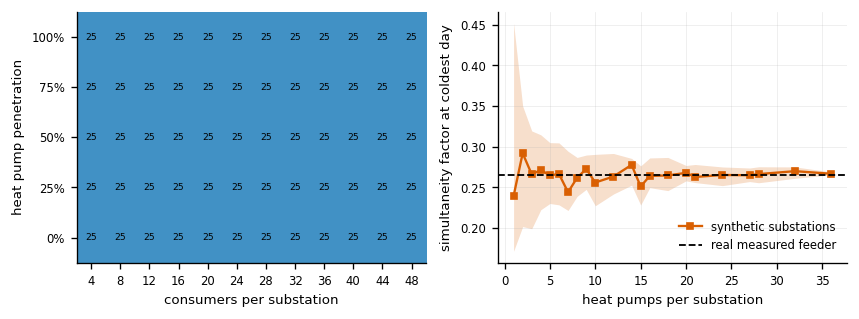

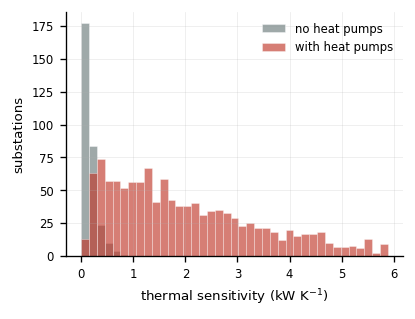

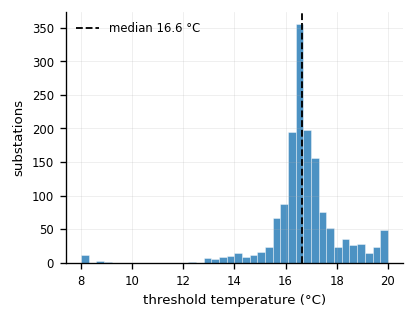

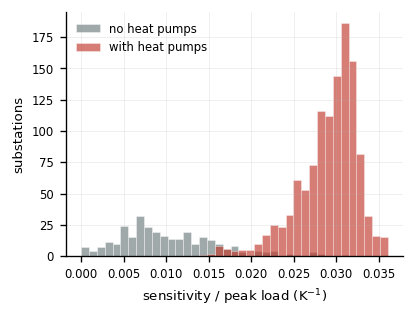

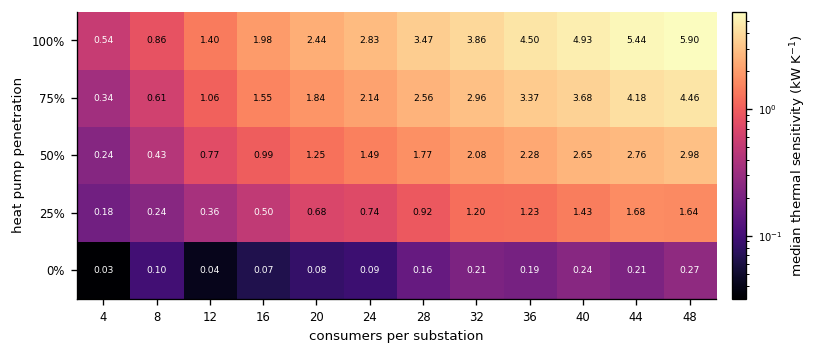

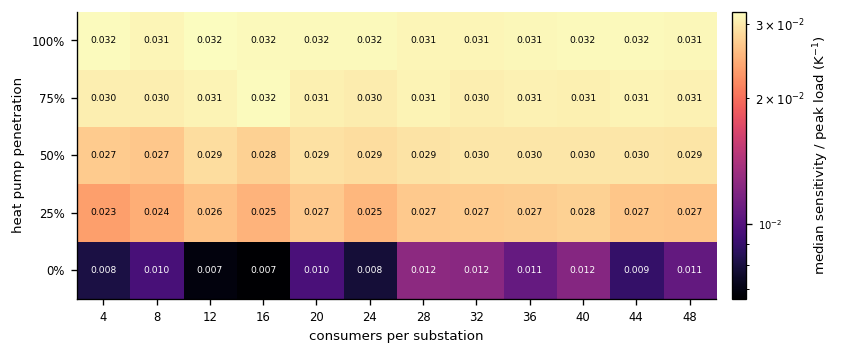

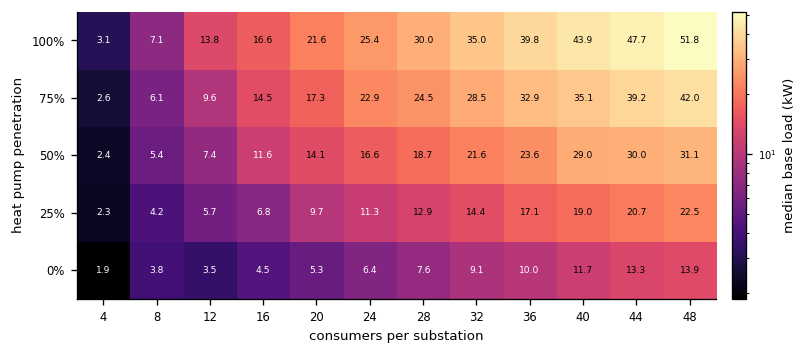

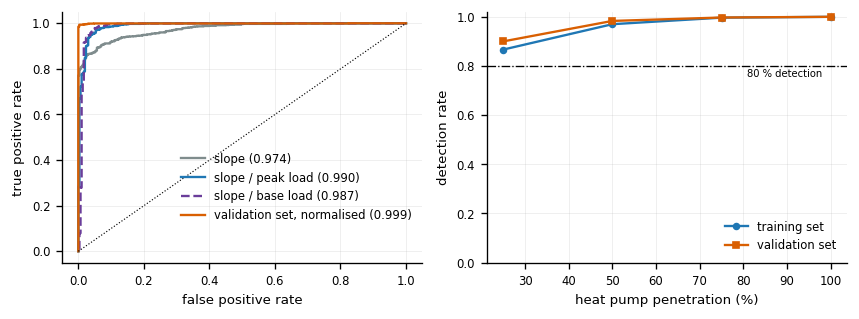

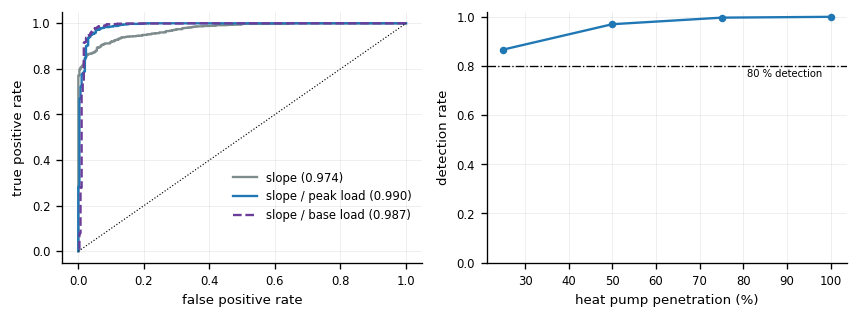

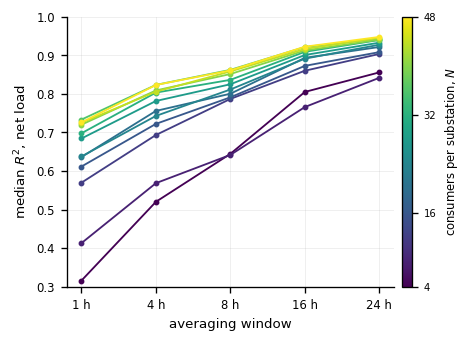

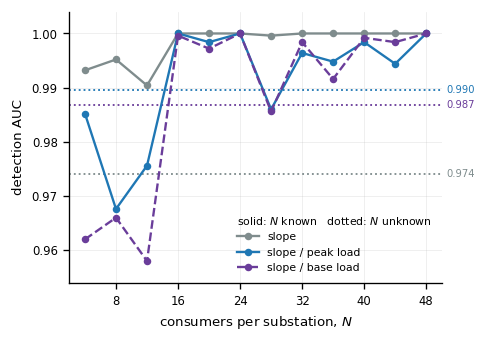

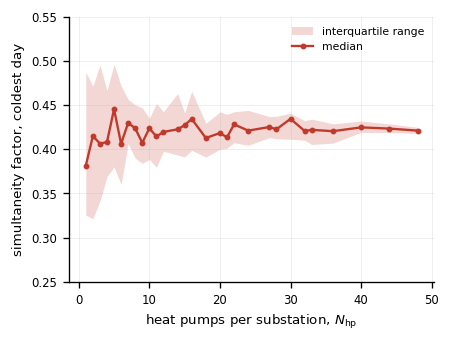

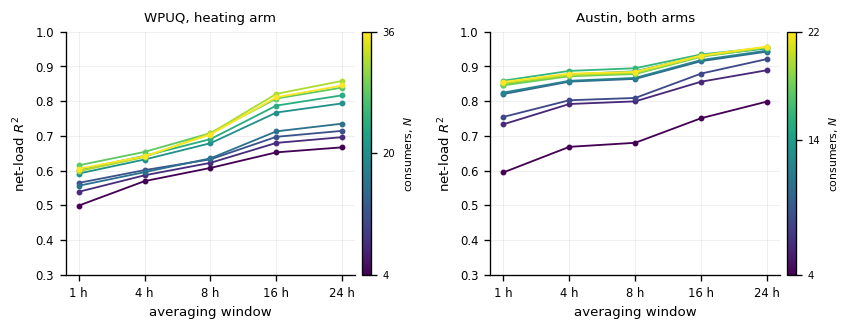

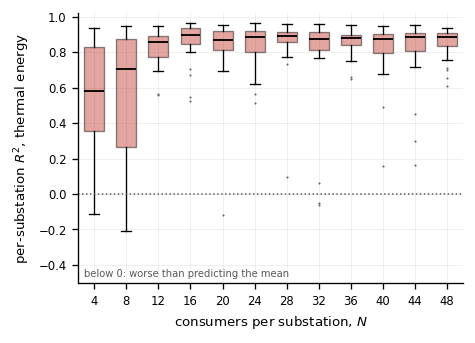

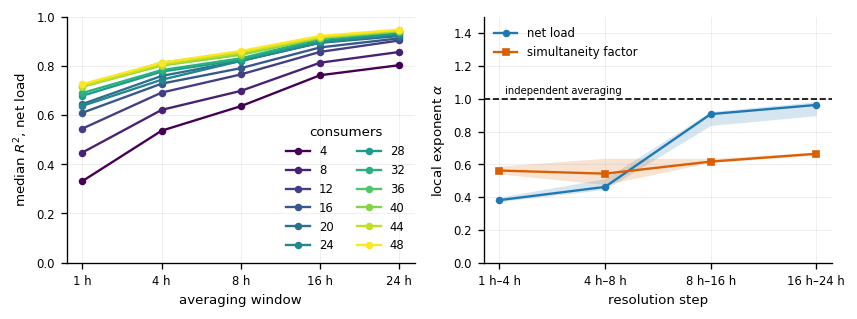

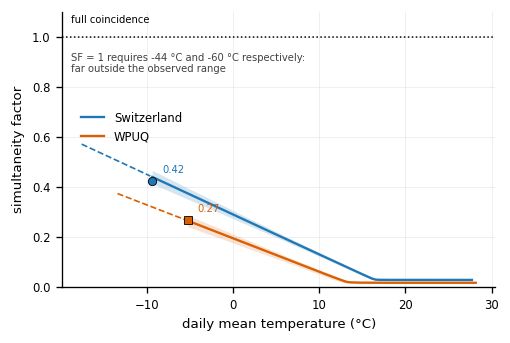

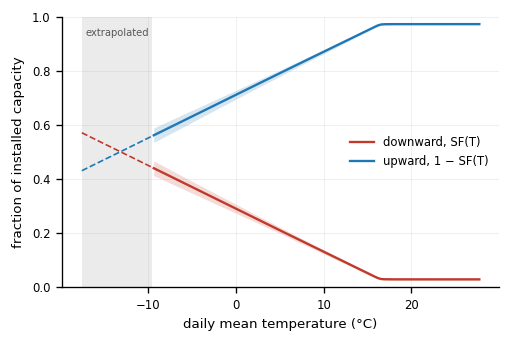

In [64]:
import hp_figures as hf
from hp_common import fit_hockey_stick

hf.use_style()

# quantities the figures need that are not already in memory
wsf24 = wpuq_sf[(wpuq_sf.resolution == '24 h') & (~wpuq_sf.failed)].copy()
wsf24['sf_cold'] = ha.sf_at_coldest(wpuq_sf, '24 h')
env_de, rng_de = ha.flexibility_envelope(wpuq_fits[wpuq_fits.response == 'SF'],
                                         wpuq_design)
# Germany is scored at the Swiss threshold rather than its own, so the two
# curves share an operating point
det_de = ha.detection_at(wpuq_load, ha.detection_threshold(
    load_fits, 'slope_per_peak', '24 h')['threshold'])
det_ch = ha.detection_threshold(load_fits, 'slope_per_peak', '24 h')
s24 = sf_fits[(sf_fits.resolution == '24 h') & (~sf_fits.failed)]
tcrit_ch = s24.T_crit.replace([np.inf, -np.inf], np.nan).median()
tcrit_de = wsf24.T_crit.replace([np.inf, -np.inf], np.nan).median()

paths = [
    hf.fig1_design(meta, wsf24, sf_real),
    *hf.fig2_slopes(d24),
    *hf.fig3_heatmap(d24),
    hf.fig4_detection(load_fits, wpuq_load, det_ch, det_de),
    # training set alone, for use before the validation set is introduced
    hf.fig4_detection(load_fits, det_ch=det_ch,
                      name='fig4_detection_train'),
    # detection at known N against detection pooled over unknown N: the
    # figure behind the within-stratum result in the paper's Detection
    # subsection. Uses load_fits at every N_total in the design.
    # fit quality against BOTH aggregation axes at once -- the anchor figure
    # for the paper's fit-quality subsection. Single panel: fig5_scaling's
    # second panel carries simultaneity factors, which the paper no longer uses.
    hf.fig_aggregation_quality(fits),
    hf.fig_within_stratum_auc(load_fits),
    # SF coincidence funnel: simultaneity factor at coldest day vs heat-pump
    # count, the paper's third aggregation-predictability readout.
    hf.fig_sf_by_aggregation(sf_fits),
    # Section IV: one nested substation per aggregation level, WPUQ.
    hf.fig_nested_aggregation(nested_fits, austin_nested),
    # Energy Estimation spread by aggregation level. Returns (path, n_hidden);
    # n_hidden is the count of substations below the clipped axis, quoted in
    # the paper's caption.
    hf.fig_energy_by_aggregation(ha.thermal_energy_per_substation(est))[0],
    hf.fig5_scaling(fits),
    # the two sf_cold_* arguments are the medians of ha.sf_at_coldest, each
    # substation on its own coldest day -- the quantity the paper tabulates.
    # Reading the median curve at the pooled coldest temperature instead would
    # mark 0.44 for Switzerland, whose substations span three weather stations.
    hf.fig6_sf(flex_ch_env if 'flex_ch_env' in dir() else flex, t_range,
               env_de, rng_de, tcrit_ch, tcrit_de,
               sf_cold_ch=ha.sf_at_coldest(sf_fits).median(),
               sf_cold_de=ha.sf_at_coldest(wpuq_sf).median()),
    hf.fig7_flexibility(flex, t_range),
]
for p in paths:
    print('written', p + '.pdf', 'and', p + '.png')


## Summary

In [65]:
print('=' * 78)
print('COMBINED HEAPO + SWISS  —  '
      f'{len(meta)} substations (N_total x hp_ratio grid, N_total <= 48), '
      f'{hh_used} households, {hp_used} with a heat pump')
print('=' * 78)

print('\nNET LOAD, daily means')
print(f'  threshold temperature : {d24.T_threshold.median():.2f} °C '
      f'[IQR {d24.T_threshold.quantile(.25):.2f}, {d24.T_threshold.quantile(.75):.2f}]')
print(f'  slope, no heat pumps  : {no_hp.slope.median():.3f} kW/°C '
      f'[IQR {no_hp.slope.quantile(.25):.3f}, {no_hp.slope.quantile(.75):.3f}]')
print(f'  slope, with heat pumps: {with_hp.slope.median():.3f} kW/°C '
      f'[IQR {with_hp.slope.quantile(.25):.3f}, {with_hp.slope.quantile(.75):.3f}]')

print('\nDETECTION  (95 % specificity)')
for _s in ['slope', 'slope_per_peak']:
    _b = boot.set_index('statistic').loc[_s]
    print(f'  {_s:16s} threshold {_b.threshold:.4f} [{_b.thr_lo:.4f}, {_b.thr_hi:.4f}]'
          f'   AUC {_b.auc:.3f} [{_b.auc_lo:.3f}, {_b.auc_hi:.3f}]'
          f'   sens {_b.sensitivity:.2f} [{_b.sens_lo:.2f}, {_b.sens_hi:.2f}]')
_p = det_norm['by_hp_ratio']
_ok = _p[_p > 0.8]
print(f'  lowest penetration over 80 % detection: '
      f'{(f"{_ok.index[0]:.0%}" if len(_ok) else "not reached")}')
_best = res_contrast.loc[res_contrast.auc.idxmax()]
print(f'  best resolution for detection: {_best.resolution} (AUC {_best.auc:.3f}); '
      f'paired gain over 24 h {_best.d_auc_vs_ref:+.3f} '
      f'[{_best.d_auc_lo:+.3f}, {_best.d_auc_hi:+.3f}], '
      f'sensitivity {_best.d_sens_vs_ref:+.3f} '
      f'[{_best.d_sens_lo:+.3f}, {_best.d_sens_hi:+.3f}]')

print('\nSIMULTANEITY FACTOR, daily means')
print(f'  threshold temperature : {s24.T_threshold.median():.2f} °C '
      f'[IQR {s24.T_threshold.quantile(.25):.2f}, {s24.T_threshold.quantile(.75):.2f}]')
print(f'  slope                 : {s24.slope.median():.4f} 1/°C '
      f'[IQR {s24.slope.quantile(.25):.4f}, {s24.slope.quantile(.75):.4f}]')
print(f'  SF at coldest observed: {sf24.SF_at_coldest.median():.2f} '
      f'[IQR {sf24.SF_at_coldest.quantile(.25):.2f}, '
      f'{sf24.SF_at_coldest.quantile(.75):.2f}]')
print(f'      per substation on its own coldest day, median over '
      f'{len(sf24)} substations')

print('\nFIT QUALITY')
_qm = ha.quality_model(fits, 'Load').set_index('term')
print(f'  per e-fold of Δt   : {_qm.loc["log_dt", "coef"]:+.3f} logit R²')
print(f'  per e-fold of N_hp : {_qm.loc["log_Nhp", "coef"]:+.3f}')
print(f'  per e-fold of N    : {_qm.loc["log_N", "coef"]:+.3f} (non-HP consumers dilute)')



COMBINED HEAPO + SWISS  —  1500 substations (N_total x hp_ratio grid, N_total <= 48), 1384 households, 77 with a heat pump

NET LOAD, daily means
  threshold temperature : 16.64 °C [IQR 16.29, 17.20]
  slope, no heat pumps  : 0.122 kW/°C [IQR 0.058, 0.226]
  slope, with heat pumps: 1.681 kW/°C [IQR 0.872, 2.915]

DETECTION  (95 % specificity)
  slope            threshold 0.4518 [0.3611, 0.4950]   AUC 0.974 [0.967, 0.981]   sens 0.88 [0.85, 0.91]
  slope_per_peak   threshold 0.0218 [0.0183, 0.0230]   AUC 0.990 [0.983, 0.995]   sens 0.96 [0.92, 0.98]
  lowest penetration over 80 % detection: 25%
  best resolution for detection: 8 h (AUC 0.994); paired gain over 24 h +0.005 [+0.001, +0.010], sensitivity +0.013 [-0.002, +0.038]

SIMULTANEITY FACTOR, daily means
  threshold temperature : 16.44 °C [IQR 16.10, 16.68]
  slope                 : 0.0160 1/°C [IQR 0.0149, 0.0171]
  SF at coldest observed: 0.42 [IQR 0.39, 0.45]
      per substation on its own coldest day, median over 1200 substatio

  per e-fold of Δt   : +0.598 logit R²
  per e-fold of N_hp : +0.760
  per e-fold of N    : -0.257 (non-HP consumers dilute)
